# Quantum-Enhanced Policy Optimisation for Autonomous Drone Navigation
## Experimental & Results Section — Full Numerical Pipeline

This notebook implements, end to end, the experimental pipeline behind the
manuscript *"Quantum-Enhanced Policy Optimisation for Autonomous Drone
Navigation: A Hybrid Quantum-Classical Reinforcement Learning Framework
with Provable Convergence Guarantees"* (QACLDN).

It is a **from-scratch, self-contained implementation** — no Qiskit,
PennyLane, Stable-Baselines3, or PyTorch dependency — built entirely on
NumPy/SciPy so every number in every figure is produced by code that is
fully inspectable in this notebook. It covers:

1. Real-data ingestion and preprocessing (UAV telemetry log, ICMCIS
   multi-sensor drone-detection radar/RF logs) used to calibrate the
   stochastic wind model, obstacle statistics and sensor-noise floor.
2. A from-scratch statevector quantum-circuit simulator implementing the
   exact hardware-efficient VQC of the manuscript (data re-uploading,
   parameterised rotation layers, alternating CNOT entangling layers,
   Pauli-Z readout) together with the analytic parameter-shift rule.
3. A 12-state rigid-body quadrotor simulator (Newton–Euler dynamics,
   RK4 integration, motor allocation matrix, von Kármán-type turbulence)
   matching Eqs. (translational/rotational dynamics) of the manuscript.
4. The Quantum Actor-Critic (QACLDN) agent: quantum policy gradient via
   parameter-shift, quantum Bellman TD-error, Grover-inspired
   visitation-based exploration bonus.
5. Classical baselines built from the same primitives: PPO (clipped
   surrogate + GAE), a soft (entropy-regularised) actor-critic (SAC-style),
   DQN (replay buffer + target network), and a non-entangled VQC ablation
   (VQC-NE).
6. The full experimental battery of the manuscript's Numerical Experiments
   section: learning curves, obstacle-density scalability, trajectory
   quality after convergence, NISQ depolarising-noise resilience, the
   (qubits, layers) performance map, wind-disturbance robustness, sample
   complexity vs. qubit count, and policy-gradient variance.
7. Real-world sensor validation subplots computed directly from the
   ICMCIS radar/RF dataset and the UAV telemetry log.

All figures are rendered as complex, multi-panel, publication-grade
matplotlib compositions and written to a single multi-page PDF.

**Honesty note on scope.** Full replication of the paper's exact episode
budgets (thousands of episodes across dozens of seeds) is not feasible in
an interactive notebook session. We therefore use reduced-but-real
training budgets (documented in `CONFIG` below) — every curve, table
entry and heatmap cell in this notebook is computed from actual policy
rollouts of the physics/quantum simulators implemented here, not
reproductions of the manuscript's placeholder numbers. Trends should
match the manuscript qualitatively; exact quantitative values will differ
from the (illustrative) numbers printed in the LaTeX source.

In [1]:
# =============================================================================
# SECTION 0 — IMPORTS, GLOBAL CONFIGURATION, REPRODUCIBILITY
# =============================================================================
from __future__ import annotations

import os
import io
import json
import time
import math
import warnings
import itertools
import dataclasses
from dataclasses import dataclass, field
from typing import Callable, Optional, Sequence

import numpy as np
import pandas as pd
import scipy.stats as sps
import scipy.signal as spsig
import scipy.linalg as spla

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Circle, FancyArrowPatch, Rectangle
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401  (registers 3-D projection)
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

warnings.filterwarnings("ignore")
try:
    from IPython.display import display, Image
except ImportError:
    def display(*a, **k):
        pass
    Image = None

# -----------------------------------------------------------------------
# Global reproducibility
# -----------------------------------------------------------------------
GLOBAL_SEED = 20260913
np.random.seed(GLOBAL_SEED)

# -----------------------------------------------------------------------
# Journal-style plotting theme (mirrors the manuscript's TikZ colour set:
# dblue / dred / dgreen / dorange / dpurple / dcyan / charcoal / midgray)
# -----------------------------------------------------------------------
PALETTE = {
    "dblue":   "#1b4f8c",
    "dred":    "#a3282f",
    "dgreen":  "#2e7d4f",
    "dorange": "#c97a1f",
    "dpurple": "#6b3fa0",
    "dcyan":   "#1f8a8c",
    "charcoal": "#2b2b2e",
    "midgray": "#8c8c94",
    "lblue":   "#cfe0f2",
    "lred":    "#f2d3d5",
    "lgreen":  "#d6ecdd",
    "lorange": "#f4e0c4",
    "lpurple": "#e1d4ef",
}

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "font.family": "serif",
    "font.size": 9.5,
    "axes.titlesize": 10.5,
    "axes.titleweight": "bold",
    "axes.labelsize": 9.5,
    "axes.edgecolor": PALETTE["charcoal"],
    "axes.linewidth": 0.8,
    "xtick.labelsize": 8.5,
    "ytick.labelsize": 8.5,
    "legend.fontsize": 8,
    "grid.color": PALETTE["midgray"],
    "grid.alpha": 0.25,
    "grid.linewidth": 0.4,
    "axes.grid": True,
    "text.usetex": False,
})

OUT_DIR = "/home/claude/work/outputs"
FIG_DIR = os.path.join(OUT_DIR, "figures")
os.makedirs(FIG_DIR, exist_ok=True)

# -----------------------------------------------------------------------
# CONFIG — all experimental hyperparameters live here (single source of
# truth). Values in [square brackets in comments] show the manuscript's
# original setting; where we reduce it for notebook-feasible runtime, the
# reduction factor is noted.
# -----------------------------------------------------------------------
@dataclass
class Config:
    # --- Quadrotor physical parameters (Appendix "Quadrotor Parameter
    # Table") — standard small quadrotor values, consistent with the
    # PyBullet "cf2x" Crazyflie-class model referenced in the manuscript.
    mass: float = 0.027 * 33.0          # kg  (scaled small quad, ~0.9 kg)
    g: float = 9.81                      # m/s^2
    Jx: float = 1.4e-2                   # kg m^2
    Jy: float = 1.4e-2                   # kg m^2
    Jz: float = 2.2e-2                   # kg m^2
    arm_length: float = 0.20             # m
    thrust_to_weight_max: float = 2.5    # max total thrust / weight (typical small quad)
    torque_thrust_ratio: float = 0.015   # c_Q / c_T (typical propeller drag/thrust ratio)
    Kp_att: float = 0.55                 # inner-loop self-levelling gain [Nm/rad]
    Kd_att: float = 0.12                 # inner-loop rate-damping gain [Nm/(rad/s)]

    # --- Simulation / episode configuration
    dt: float = 0.02                      # s   [manuscript: 0.02 s]
    T_episode: int = 200                  # steps [manuscript: 500] -- reduced
                                           # for notebook runtime; dynamics
                                           # and reward model are identical.
    T_short: int = 80                     # short-horizon episodes used only
                                           # in the qubit/layer sweeps, where
                                           # relative (not absolute) trends
                                           # across many configurations matter.
    T_eval_episode: int = 120

    # --- QMDP / VQC configuration
    n_S: int = 4
    n_A: int = 4
    n_qubits_default: int = 6             # n_S + n_A (reduced from n=8 for
                                           # circuit-simulation runtime; the
                                           # full n=8,10 configurations are
                                           # still explored in the qubit
                                           # sample-complexity sweep below)
    L_layers_default: int = 2
    n_actions: int = 16                   # |A| = 2^{n_A}

    # --- Reward shaping weights (Eq. reward_function)
    lambda_g: float = 6.0
    lambda_c: float = 2.5                 # reduced from 4.0: was dominating the goal
                                           # signal and suppressing goal-directed learning
    lambda_e: float = 0.35
    lambda_s: float = 0.06
    lambda_v: float = 0.20
    sigma_g: float = 2.2                  # goal-reward kernel width [m] -- widened so
                                           # the shaping gradient extends across most of
                                           # the (now smaller) arena
    d_safe: float = 0.55                  # collision safety radius [m]
    v_max: float = 3.5                    # velocity safety threshold [m/s]

    # --- Environment geometry
    world_size: float = 2.6               # cubic arena half-extent [m] -- sized
                                           # so the start->goal distance is
                                           # reachable within T_episode at the
                                           # quadrotor's achievable cruise speed
                                           # (verified empirically below)
    n_obstacles_default: int = 4

    # --- Wind / turbulence (von Karman-type OU process)
    tau_w: float = 2.0                    # correlation time [s]

    # --- Training budgets (reduced from manuscript's ~1200 episodes to
    # keep total wall-clock time for the *entire* notebook, across ~6
    # methods x several ablation sweeps, tractable -- see the "Honesty
    # note on scope" in the introduction cell)
    n_episodes_main: int = 150            # [manuscript: 1200]
    n_seeds_main: int = 3                 # [manuscript: not fully reported]
    batch_episodes: int = 4               # episodes per policy-gradient update
    gamma: float = 0.99
    actor_lr: float = 0.05
    critic_lr: float = 0.12
    entropy_coef: float = 0.01

    # --- Scalability sweep
    obstacle_counts: tuple = (2, 4, 6, 8, 10, 12)
    n_episodes_scalability: int = 45
    seeds_scalability: int = 2

    # --- Sample-complexity sweep (qubit count)
    qubit_sweep: tuple = (2, 4, 6, 8)
    n_episodes_sample_complexity: int = 30
    return_threshold_frac: float = 0.85   # fraction of best return = "converged"

    # --- (n, L) performance map
    layer_sweep: tuple = (1, 2, 3)
    qubit_sweep_map: tuple = (4, 6, 8)
    n_episodes_map: int = 20

    # --- Wind robustness sweep (evaluation only, reuses trained policies)
    wind_levels: tuple = (0.0, 0.1, 0.2, 0.3, 0.4, 0.5)  # x g
    n_eval_episodes_wind: int = 20

    # --- NISQ noise resilience sweep (evaluation only)
    noise_levels: tuple = (0.0, 0.0005, 0.001, 0.002, 0.005, 0.01)
    n_eval_episodes_noise: int = 30

    # --- Final trajectory-quality evaluation
    n_test_episodes: int = 60


CFG = Config()
print(f"[config] mass={CFG.mass:.3f} kg, dt={CFG.dt}s, episode={CFG.T_episode} "
      f"steps ({CFG.T_episode*CFG.dt:.1f}s of flight)")
print(f"[config] training budget: {CFG.n_episodes_main} episodes x "
      f"{CFG.n_seeds_main} seeds per method (main comparison)")

[config] mass=0.891 kg, dt=0.02s, episode=200 steps (4.0s of flight)
[config] training budget: 150 episodes x 3 seeds per method (main comparison)


## Section 1 — Real-Data Ingestion & Preprocessing

Two real datasets calibrate the simulator:

* **UAV telemetry log** (`uav_navigation_dataset.csv`, 5000 rows): GPS
  position, IMU accelerations/gyro rates, LiDAR range, ground speed,
  wind speed, battery level and a binary obstacle-detection flag, sampled
  at 1 Hz. We use this to (i) fit the turbulence correlation time and
  intensity of the von Kármán wind model empirically, rather than only
  assuming the manuscript's $\tau_w = 2\,$s, and (ii) characterise the
  realistic LiDAR/IMU sensor-noise floor for the observation model.
* **ICMCIS drone-detection challenge dataset** (multi-sensor: ALVIRA
  radar, ARCUS radar, DIANA RF sensor, VENUS acoustic sensor, across
  several real flight scenarios): used to derive realistic obstacle
  radial-distance / RCS / SNR statistics for the sensor-validation
  subplots, grounding the "obstacle field" abstraction in real
  multi-sensor tracking data.

In [2]:
# =============================================================================
# SECTION 1.1 — UAV telemetry log
# =============================================================================
UAV_CSV = "/home/claude/work/data/archive/uav_navigation_dataset.csv"

uav_df = pd.read_csv(UAV_CSV, parse_dates=["timestamp"])
uav_df = uav_df.sort_values("timestamp").reset_index(drop=True)

# Basic cleaning: clip physically implausible IMU spikes (>6 sigma) using a
# robust (MAD-based) filter rather than a naive fixed threshold.
def mad_clip(series: pd.Series, n_mad: float = 6.0) -> pd.Series:
    med = series.median()
    mad = (series - med).abs().median() * 1.4826 + 1e-9
    lo, hi = med - n_mad * mad, med + n_mad * mad
    return series.clip(lo, hi)

for col in ["imu_acc_x", "imu_acc_y", "imu_acc_z",
            "imu_gyro_x", "imu_gyro_y", "imu_gyro_z",
            "lidar_distance", "speed", "wind_speed", "battery_level"]:
    uav_df[col] = mad_clip(uav_df[col])

uav_df["dt_s"] = uav_df["timestamp"].diff().dt.total_seconds().fillna(1.0)
uav_df["accel_mag"] = np.sqrt(uav_df.imu_acc_x**2 + uav_df.imu_acc_y**2 + uav_df.imu_acc_z**2)
uav_df["gyro_mag"] = np.sqrt(uav_df.imu_gyro_x**2 + uav_df.imu_gyro_y**2 + uav_df.imu_gyro_z**2)

print(f"[data] UAV telemetry: {len(uav_df)} rows, "
      f"{uav_df.timestamp.min()} -> {uav_df.timestamp.max()}")
print(f"[data] obstacle_detected rate: {uav_df.obstacle_detected.mean()*100:.2f}%")


# --- Empirical wind-turbulence calibration -----------------------------
# The manuscript models wind as an Ornstein-Uhlenbeck / von Karman process
#     dxi = -(1/tau_w) xi dt + sigma dW,   Cov[xi(t)xi(t')] = sigma^2 exp(-|t-t'|/tau_w)
# We estimate tau_w directly from the empirical autocorrelation function
# (ACF) of the logged wind_speed signal: for an OU process the ACF decays
# as exp(-|k| dt / tau_w), so tau_w = -dt / ln(rho_1) using the lag-1
# autocorrelation rho_1 (least-squares fit across the first few lags for
# robustness).
def fit_ou_tau(signal: np.ndarray, dt: float, max_lag: int = 8) -> float:
    signal = signal - signal.mean()
    denom = np.dot(signal, signal)
    acf = np.array([np.dot(signal[:-k], signal[k:]) / denom if k > 0 else 1.0
                     for k in range(max_lag + 1)])
    acf = np.clip(acf, 1e-4, 1.0)
    lags = np.arange(max_lag + 1) * dt
    # log(acf) = -lag / tau_w  =>  linear regression through origin
    slope = -np.sum(lags * np.log(acf)) / np.sum(lags**2 + 1e-12)
    tau = 1.0 / max(slope, 1e-6)
    return float(np.clip(tau, 0.2, 30.0))


wind_signal = uav_df["wind_speed"].to_numpy()
tau_w_empirical = fit_ou_tau(wind_signal, dt=1.0)
sigma_w_empirical = float(wind_signal.std())
print(f"[calibration] empirical wind OU correlation time tau_w "
      f"= {tau_w_empirical:.2f} s  (manuscript default: {CFG.tau_w:.2f} s)")
print(f"[calibration] empirical wind intensity sigma_w "
      f"= {sigma_w_empirical:.3f} m/s")

# Sensor noise floor (used later to size the quantum-encoding resolution
# discussion and the observation-noise term in the environment)
lidar_noise_std = float(uav_df["lidar_distance"].diff().std() / np.sqrt(2))
imu_noise_std = float(uav_df["accel_mag"].diff().std() / np.sqrt(2))
print(f"[calibration] LiDAR increment noise std ~= {lidar_noise_std:.3f} m")
print(f"[calibration] IMU accel-magnitude increment noise std ~= {imu_noise_std:.3f} m/s^2")

[data] UAV telemetry: 5000 rows, 2023-01-01 00:00:00 -> 2023-01-01 01:23:19
[data] obstacle_detected rate: 4.72%
[calibration] empirical wind OU correlation time tau_w = 0.63 s  (manuscript default: 2.00 s)
[calibration] empirical wind intensity sigma_w = 5.768 m/s
[calibration] LiDAR increment noise std ~= 28.799 m
[calibration] IMU accel-magnitude increment noise std ~= 0.828 m/s^2


In [3]:
# =============================================================================
# SECTION 1.2 — ICMCIS multi-sensor drone-detection dataset
# =============================================================================
ICMCIS_ROOT = "/home/claude/work/data/icmcis/icmcis-drone-detection (2)"

ICMCIS_SCENARIOS = [
    "train/train/Scenario_1_1",
    "train/train/Scenario_1_3",
    "train/train/Scenario_1_4",
    "train/train/Scenario_2_1",
    "train/train/Scenario_Parrot_a",
]

def load_alvira(scn: str) -> pd.DataFrame:
    path = os.path.join(ICMCIS_ROOT, scn, "ALVIRA_scenario.csv")
    df = pd.read_csv(path)
    keep = ["AlviraTracksTrack_Timestamp", "AlviraTracksTrackPosition_Latitude",
            "AlviraTracksTrackPosition_Longitude", "AlviraTracksTrackPosition_Altitude",
            "AlviraTracksTrackVelocity_Speed", "AlviraTracksTrack_Score"]
    df = df[keep].copy()
    df["scenario"] = scn.split("/")[-1]
    df["sensor"] = "ALVIRA"
    return df

def load_diana(scn: str) -> pd.DataFrame:
    path = os.path.join(ICMCIS_ROOT, scn, "DIANA_scenario.csv")
    df = pd.read_csv(path)
    keep = ["DianaTargetsTargetSignal_snr_dB", "DianaTargetsTargetSignal_bearing_deg",
            "DianaTargetsTargetSignal_range_m", "DianaTargetsTargetClassification_score",
            "DianaTargetsTargetClassification_type"]
    df = df[keep].copy()
    df["scenario"] = scn.split("/")[-1]
    df["sensor"] = "DIANA"
    return df

alvira_frames, diana_frames = [], []
for scn in ICMCIS_SCENARIOS:
    try:
        alvira_frames.append(load_alvira(scn))
    except Exception as exc:
        print(f"[data] ALVIRA {scn} skipped: {exc}")
    try:
        diana_frames.append(load_diana(scn))
    except Exception as exc:
        print(f"[data] DIANA {scn} skipped: {exc}")

alvira_df = pd.concat(alvira_frames, ignore_index=True)
diana_df = pd.concat(diana_frames, ignore_index=True)

alvira_tracks = alvira_df.dropna(subset=["AlviraTracksTrackPosition_Altitude"]).copy()
diana_targets = diana_df.dropna(subset=["DianaTargetsTargetSignal_snr_dB"]).copy()

print(f"[data] ICMCIS ALVIRA radar: {len(alvira_tracks)} track detections "
      f"across {alvira_tracks.scenario.nunique()} scenarios")
print(f"[data] ICMCIS DIANA RF sensor: {len(diana_targets)} target detections "
      f"across {diana_targets.scenario.nunique()} scenarios")

# --- Real-world radial-distance & RCS statistics used to calibrate the
# simulated obstacle field's "sensor-detectability" radius d_safe, and the
# SNR-vs-range relation used in the sensor-validation subplot.
alvira_speed = alvira_tracks["AlviraTracksTrackVelocity_Speed"].dropna()
alvira_score = alvira_tracks["AlviraTracksTrack_Score"].dropna()
diana_range = diana_targets["DianaTargetsTargetSignal_range_m"].dropna()
diana_snr = diana_targets["DianaTargetsTargetSignal_snr_dB"].dropna()

print(f"[calibration] ALVIRA track speed: mean={alvira_speed.mean():.2f} m/s, "
      f"std={alvira_speed.std():.2f} m/s")
print(f"[calibration] DIANA range: mean={diana_range.mean():.1f} m, "
      f"median={diana_range.median():.1f} m")

# Empirical radar-equation fit: SNR (dB) ~= A - 10*n*log10(range).  We fit
# the effective path-loss exponent n_pl by ordinary least squares on the
# real DIANA range/SNR pairs; this is later used to build a physically
# grounded "detectability envelope" annotation on the sensor-validation
# figure.
mask = (diana_range > 1) & np.isfinite(diana_snr)
X_pl = np.vstack([np.ones(mask.sum()), -10 * np.log10(diana_range[mask])]).T
y_pl = diana_snr[mask].to_numpy()
coef_pl, *_ = np.linalg.lstsq(X_pl, y_pl, rcond=None)
A_fit, n_pl_fit = coef_pl[0], coef_pl[1]
print(f"[calibration] fitted radar path-loss exponent n_pl = {n_pl_fit:.3f}, "
      f"intercept A = {A_fit:.2f} dB")

[data] ICMCIS ALVIRA radar: 1311 track detections across 5 scenarios
[data] ICMCIS DIANA RF sensor: 2681 target detections across 5 scenarios
[calibration] ALVIRA track speed: mean=12.01 m/s, std=9.72 m/s
[calibration] DIANA range: mean=249.7 m, median=180.0 m
[calibration] fitted radar path-loss exponent n_pl = 1.994, intercept A = 64.83 dB


## Section 2 — Quadrotor Rigid-Body Dynamics

Implements the manuscript's Newton–Euler equations exactly:
$$ m\ddot{\bm r} = -mg\bm e_3 + R(\phi,\theta,\psi)\bm F_T + \bm F_w(t), \qquad
   \bm J\dot{\bm\omega} = -\bm\omega\times \bm J\bm\omega + \bm\tau_T + \bm\tau_d(t) $$
with the motor allocation matrix mapping four squared motor commands to
total thrust and body torques, integrated with RK4 at $\Delta t = 0.02$ s,
and a von Kármán-type Ornstein-Uhlenbeck turbulence process for $\bm F_w(t)$.

In [4]:
# =============================================================================
# SECTION 2.1 — Rotation matrix, motor allocation, and OU wind process
# =============================================================================
def rotation_matrix_zyx(phi: float, theta: float, psi: float) -> np.ndarray:
    """Body-to-world rotation matrix R(phi,theta,psi) in ZYX (yaw-pitch-roll)
    Euler-angle convention, as used throughout the manuscript."""
    cphi, sphi = math.cos(phi), math.sin(phi)
    cth, sth = math.cos(theta), math.sin(theta)
    cpsi, spsi = math.cos(psi), math.sin(psi)
    R = np.array([
        [cpsi*cth, cpsi*sth*sphi - spsi*cphi, cpsi*sth*cphi + spsi*sphi],
        [spsi*cth, spsi*sth*sphi + cpsi*cphi, spsi*sth*cphi - cpsi*sphi],
        [-sth,     cth*sphi,                  cth*cphi],
    ])
    return R


def euler_rate_matrix(phi: float, theta: float) -> np.ndarray:
    """Maps body-frame angular rates (p,q,r) to Euler-angle rates
    (phi_dot, theta_dot, psi_dot); singular at theta = +-pi/2 (not visited
    in the bounded-attitude regime enforced by the environment)."""
    cphi, sphi = math.cos(phi), math.sin(phi)
    cth = math.cos(theta)
    cth = np.clip(cth, 1e-3, None) if cth >= 0 else np.clip(cth, None, -1e-3)
    tth = math.tan(theta)
    return np.array([
        [1.0, sphi*tth, cphi*tth],
        [0.0, cphi,     -sphi],
        [0.0, sphi/cth, cphi/cth],
    ])


def build_allocation_matrix(cfg: Config) -> np.ndarray:
    """Motor allocation matrix M of Eq. (motor_mapping): maps
    [u1^2,u2^2,u3^2,u4^2] (normalised squared motor commands) to
    [T_total, tau_phi, tau_theta, tau_psi]."""
    # Per-motor thrust coefficient c_T is sized so that four motors at full
    # command (u=1) deliver thrust_to_weight_max x weight; hence at the
    # hover command u_hover = 1/sqrt(thrust_to_weight_max) the net thrust
    # exactly balances gravity (verified numerically below).
    c_T = cfg.thrust_to_weight_max * cfg.mass * cfg.g / 4.0
    c_Q = cfg.torque_thrust_ratio * c_T
    ell = cfg.arm_length
    M = np.array([
        [c_T,      c_T,      c_T,      c_T],
        [0.0,      ell*c_T,  0.0,     -ell*c_T],
        [-ell*c_T, 0.0,      ell*c_T,  0.0],
        [c_Q,     -c_Q,      c_Q,     -c_Q],
    ])
    return M


class OUWindProcess:
    """Ornstein-Uhlenbeck / von Karman turbulence generator:
        d xi = -(1/tau_w) xi dt + sigma sqrt(2/tau_w) dW
    which has stationary covariance sigma^2 exp(-|t-t'|/tau_w), matching
    Eq. (wind_model) of the manuscript. Exact discrete-time update:
        xi_{k+1} = xi_k * a + sigma * sqrt(1-a^2) * N(0,1),  a = exp(-dt/tau_w)
    """
    def __init__(self, sigma: float, tau_w: float, dt: float, dim: int, rng: np.random.Generator):
        self.a = math.exp(-dt / tau_w)
        self.sigma = sigma
        self.dim = dim
        self.rng = rng
        self.state = np.zeros(dim)

    def reset(self):
        self.state = self.rng.normal(0.0, self.sigma, size=self.dim)

    def step(self) -> np.ndarray:
        noise = self.rng.normal(0.0, 1.0, size=self.dim)
        self.state = self.a * self.state + self.sigma * math.sqrt(max(1 - self.a**2, 0.0)) * noise
        return self.state.copy()


# =============================================================================
# SECTION 2.2 — 12-state rigid-body simulator with RK4 integration
# =============================================================================
class QuadrotorDynamics:
    """Full 12-state quadrotor: s = [x,y,z, xdot,ydot,zdot, phi,theta,psi, p,q,r]."""

    STATE_DIM = 12

    def __init__(self, cfg: Config, rng: np.random.Generator):
        self.cfg = cfg
        self.rng = rng
        self.M = build_allocation_matrix(cfg)
        self.J = np.diag([cfg.Jx, cfg.Jy, cfg.Jz])
        self.Jinv = np.linalg.inv(self.J)

    def motor_to_wrench(self, u: np.ndarray) -> np.ndarray:
        """u in [0,1]^4 motor commands -> [T_total, tau_phi, tau_theta, tau_psi]."""
        u2 = np.clip(u, 0.0, 1.0) ** 2
        return self.M @ u2

    def deriv(self, s: np.ndarray, u: np.ndarray, F_w: np.ndarray, tau_d: np.ndarray) -> np.ndarray:
        cfg = self.cfg
        pos, vel, att, rates = s[0:3], s[3:6], s[6:9], s[9:12]
        phi, theta, psi = att
        p, q, r = rates

        wrench = self.motor_to_wrench(u)
        T_total, tau_phi, tau_theta, tau_psi = wrench
        R = rotation_matrix_zyx(phi, theta, psi)
        F_T_body = np.array([0.0, 0.0, T_total])

        # Translational dynamics: Eq. (translational_dynamics)
        accel = (-cfg.mass * cfg.g * np.array([0.0, 0.0, 1.0])
                 + R @ F_T_body + F_w) / cfg.mass

        # Rotational dynamics: Eq. (rotational_dynamics), augmented with the
        # inner-loop rate/attitude stabilisation every real (and essentially
        # every simulated, e.g. gym-pybullet-drones' PID control mode)
        # quadrotor flight stack provides beneath a high-level RL/planning
        # command: a fast attitude-rate damper (tau_stab = -Kd*omega) plus a
        # mild self-levelling restoring torque (-Kp*[phi,theta,0]) that
        # prevents runaway tilt when the discrete high-level action commands
        # a sustained pitch/roll bias. This does not add any translational
        # authority the RL agent doesn't already command via `u` -- it only
        # keeps the attitude loop from diverging, exactly as a real flight
        # controller's inner loop does beneath an outer-loop RL policy.
        omega = rates
        tau_T = np.array([tau_phi, tau_theta, tau_psi])
        tau_stab = (-cfg.Kp_att * np.array([phi, theta, 0.0])
                    - cfg.Kd_att * omega)
        omega_dot = self.Jinv @ (-np.cross(omega, self.J @ omega) + tau_T + tau_stab + tau_d)

        E = euler_rate_matrix(phi, theta)
        att_dot = E @ rates

        return np.concatenate([vel, accel, att_dot, omega_dot])

    def rk4_step(self, s: np.ndarray, u: np.ndarray, F_w: np.ndarray,
                 tau_d: np.ndarray, dt: float) -> np.ndarray:
        k1 = self.deriv(s, u, F_w, tau_d)
        k2 = self.deriv(s + 0.5*dt*k1, u, F_w, tau_d)
        k3 = self.deriv(s + 0.5*dt*k2, u, F_w, tau_d)
        k4 = self.deriv(s + dt*k3, u, F_w, tau_d)
        s_next = s + (dt/6.0) * (k1 + 2*k2 + 2*k3 + k4)
        # Bound attitude to avoid Euler-angle singularities (standard
        # practical safeguard; does not affect the dynamics equations)
        s_next[6:8] = np.clip(s_next[6:8], -1.3, 1.3)
        # Angular-rate clipping: represents aerodynamic/rotor damping not
        # explicitly modelled in the rigid-body torque balance; without
        # this a constant differential-thrust command integrates without
        # bound over a held action. Bound consistent with small-quadrotor
        # agile-flight envelopes (~|omega| <~ 12 rad/s).
        s_next[9:12] = np.clip(s_next[9:12], -12.0, 12.0)
        return s_next


print("[physics] Quadrotor dynamics module ready "
      f"(mass={CFG.mass:.3f} kg, J=diag({CFG.Jx},{CFG.Jy},{CFG.Jz}))")

[physics] Quadrotor dynamics module ready (mass=0.891 kg, J=diag(0.014,0.014,0.022))


## Section 3 — Statevector Quantum-Circuit Simulator

A from-scratch, dependency-free statevector simulator implementing the
manuscript's hardware-efficient VQC (encoding layer with data
re-uploading, parameterised $R_y R_z$ rotation layer, alternating
even/odd CNOT entangling layer, Pauli-$Z$ measurement layer), together
with the exact analytic **parameter-shift rule** for gradients of
expectation values, and an optional depolarising-noise channel for the
NISQ resilience experiments.

Single-qubit gates are applied by reshaping the $2^n$-dimensional
statevector into an $n$-axis tensor and contracting on the target axis
— $O(2^n)$ per gate, not $O(4^n)$ — so circuits with up to $n=12$ qubits
run in well under a millisecond per forward pass.

In [5]:
# =============================================================================
# SECTION 3.1 — Single/two-qubit gate primitives on a reshaped statevector
# =============================================================================
def _ry(theta: float) -> np.ndarray:
    c, s = math.cos(theta/2), math.sin(theta/2)
    return np.array([[c, -s], [s, c]], dtype=complex)

def _rz(theta: float) -> np.ndarray:
    e_m = complex(math.cos(-theta/2), math.sin(-theta/2))
    e_p = complex(math.cos(theta/2), math.sin(theta/2))
    return np.array([[e_m, 0], [0, e_p]], dtype=complex)

def apply_single_qubit_gate(state: np.ndarray, n: int, qubit: int, gate: np.ndarray) -> np.ndarray:
    """Apply a 2x2 unitary `gate` to `qubit` of an n-qubit statevector of
    length 2^n, via tensor reshape + contraction (avoids building the full
    2^n x 2^n operator)."""
    tensor = state.reshape([2] * n)
    tensor = np.tensordot(gate, tensor, axes=([1], [qubit]))
    tensor = np.moveaxis(tensor, 0, qubit)
    return tensor.reshape(-1)

def apply_cnot(state: np.ndarray, n: int, control: int, target: int) -> np.ndarray:
    tensor = state.reshape([2] * n)
    tensor = np.moveaxis(tensor, [control, target], [0, 1])
    out = tensor.copy()
    # When control=1, swap the target axis (index 1) between |.,0,...> and |.,1,...>
    out[1, 0, ...] = tensor[1, 1, ...]
    out[1, 1, ...] = tensor[1, 0, ...]
    out = np.moveaxis(out, [0, 1], [control, target])
    return out.reshape(-1)

def apply_depolarising_channel(state: np.ndarray, n: int, qubit: int, p: float,
                                rng: np.random.Generator) -> np.ndarray:
    """Single-qubit depolarising channel realised by stochastic Pauli
    twirling (Monte-Carlo unravelling): with probability p apply a
    uniformly random Pauli {X,Y,Z}, else identity. In expectation this
    reproduces the depolarising channel
        rho -> (1-p) rho + p/3 (X rho X + Y rho Y + Z rho Z)
    used to model two-qubit-gate-induced NISQ hardware noise p_2q."""
    if p <= 0.0:
        return state
    if rng.random() < p:
        pauli = rng.integers(0, 3)
        tensor = state.reshape([2] * n)
        if pauli == 0:      # X
            tensor = np.flip(tensor, axis=qubit)
        elif pauli == 1:    # Y
            tensor = np.flip(tensor, axis=qubit)
            phase = np.array([-1j, 1j])
            shape = [1] * n
            shape[qubit] = 2
            tensor = tensor * phase.reshape(shape)
        else:                # Z
            phase = np.array([1.0, -1.0])
            shape = [1] * n
            shape[qubit] = 2
            tensor = tensor * phase.reshape(shape)
        return tensor.reshape(-1)
    return state


# =============================================================================
# SECTION 3.2 — Hardware-efficient VQC (encoding + rotation + entangling)
# =============================================================================
def apply_gate_batch(state: np.ndarray, n: int, qubit: int, gate: np.ndarray) -> np.ndarray:
    """Batched single-qubit gate application. `state` has shape (B, 2^n).
    Reshapes to (B, left, 2, right) around the target qubit and contracts
    the 2x2 `gate` on that axis -- O(B * 2^n) per gate, fully vectorised."""
    B = state.shape[0]
    left = 2 ** qubit
    right = 2 ** (n - qubit - 1)
    t = state.reshape(B, left, 2, right)
    t = np.einsum('ij,blJr->bliR'.replace('J', 'j').replace('R', 'r'), gate, t) \
        if False else np.einsum('ij,bljr->blir', gate, t)
    return t.reshape(B, -1)

def apply_cnot_batch(state: np.ndarray, n: int, control: int, target: int) -> np.ndarray:
    B = state.shape[0]
    tensor = state.reshape([B] + [2] * n)
    tensor = np.moveaxis(tensor, [control + 1, target + 1], [1, 2])
    out = tensor.copy()
    out[:, 1, 0, ...] = tensor[:, 1, 1, ...]
    out[:, 1, 1, ...] = tensor[:, 1, 0, ...]
    out = np.moveaxis(out, [1, 2], [control + 1, target + 1])
    return out.reshape(B, -1)

def apply_depolarising_batch(state: np.ndarray, n: int, qubit: int, p: float,
                              rng: np.random.Generator) -> np.ndarray:
    """Batched Monte-Carlo depolarising channel (see single-state docstring
    above for the physical model); each batch element gets an independent
    noise realisation."""
    if p <= 0.0:
        return state
    B = state.shape[0]
    hit = rng.random(B) < p
    if not hit.any():
        return state
    pauli = rng.integers(0, 3, size=B)
    tensor = state.reshape([B] + [2] * n)
    idx_hit = np.where(hit)[0]
    for b in idx_hit:
        sl = [b, slice(None)] + [slice(None)] * n
        sub = tensor[b]
        if pauli[b] == 0:      # X
            tensor[b] = np.flip(sub, axis=qubit)
        elif pauli[b] == 1:    # Y
            flipped = np.flip(sub, axis=qubit)
            phase = np.array([-1j, 1j])
            shape = [1] * n
            shape[qubit] = 2
            tensor[b] = flipped * phase.reshape(shape)
        else:                    # Z
            phase = np.array([1.0, -1.0])
            shape = [1] * n
            shape[qubit] = 2
            tensor[b] = sub * phase.reshape(shape)
    return tensor.reshape(B, -1)


class VQC:
    """Hardware-efficient VQC of Eq. (vqc_layer):
        U_l(theta_l, s) = E_odd E_even R_l(theta_l) Phi_enc^(l)(s; omega_l)
    stacked over L layers, with Pauli-Z readout on all n qubits.

    Parameters are laid out as a flat vector of length 2*n*L (one Ry, one
    Rz angle per qubit per layer), matching P_rot = 2nL of the manuscript.

    All forward passes are *batched*: a single call processes an array of
    B states at once (B=1 for online action selection during rollouts,
    B = batch size during parameter-shift gradient estimation), which is
    what makes training this circuit-simulator-in-the-loop tractable
    within a notebook session -- the alternative (a Python loop issuing
    one statevector simulation per timestep per shifted parameter) is
    >100x slower for no gain in numerical accuracy.
    """

    def __init__(self, n_qubits: int, n_layers: int, entangled: bool = True):
        self.n = n_qubits
        self.L = n_layers
        self.entangled = entangled
        self.n_params = 2 * self.n * self.L
        self.dim = 2 ** self.n

    def _encode_batch(self, state: np.ndarray, s_norm: np.ndarray, layer_idx: int) -> np.ndarray:
        """s_norm: (B, d) batch of normalised, padded states. Data
        re-uploading encoding, Eq. (drone_reuploading), applied per-batch
        via angle-dependent single-qubit rotations built per example."""
        B, d = s_norm.shape
        for j in range(self.n):
            idx_y = (j + layer_idx) % d
            idx_z = (j + layer_idx + self.n) % d
            angles_y = math.pi * s_norm[:, idx_y]
            angles_z = math.pi * s_norm[:, idx_z]
            state = self._apply_ry_batch(state, j, angles_y)
            state = self._apply_rz_batch(state, j, angles_z)
        return state

    def _apply_ry_batch(self, state: np.ndarray, qubit: int, angles: np.ndarray) -> np.ndarray:
        """Per-example-angle Ry rotation (angles varies across the batch,
        unlike the shared-parameter rotation layer below)."""
        B = state.shape[0]
        left, right = 2 ** qubit, 2 ** (self.n - qubit - 1)
        t = state.reshape(B, left, 2, right)
        c, s = np.cos(angles/2), np.sin(angles/2)
        out = np.empty_like(t)
        out[:, :, 0, :] = c[:, None, None]*t[:, :, 0, :] - s[:, None, None]*t[:, :, 1, :]
        out[:, :, 1, :] = s[:, None, None]*t[:, :, 0, :] + c[:, None, None]*t[:, :, 1, :]
        return out.reshape(B, -1)

    def _apply_rz_batch(self, state: np.ndarray, qubit: int, angles: np.ndarray) -> np.ndarray:
        B = state.shape[0]
        left, right = 2 ** qubit, 2 ** (self.n - qubit - 1)
        t = state.reshape(B, left, 2, right)
        e_m = np.exp(-1j*angles/2)
        e_p = np.exp(1j*angles/2)
        out = np.empty_like(t)
        out[:, :, 0, :] = e_m[:, None, None]*t[:, :, 0, :]
        out[:, :, 1, :] = e_p[:, None, None]*t[:, :, 1, :]
        return out.reshape(B, -1)

    def _rotate_batch(self, state: np.ndarray, theta_layer: np.ndarray) -> np.ndarray:
        """Shared (non-batch-varying) parameterised rotation layer, Eq.
        (rotation_layer): same theta_layer angles broadcast across the
        whole batch."""
        for j in range(self.n):
            state = apply_gate_batch(state, self.n, j, _ry(theta_layer[2*j]))
            state = apply_gate_batch(state, self.n, j, _rz(theta_layer[2*j+1]))
        return state

    def _entangle_batch(self, state: np.ndarray) -> np.ndarray:
        if not self.entangled or self.n < 2:
            return state
        for j in range(0, self.n - 1, 2):
            state = apply_cnot_batch(state, self.n, j, j + 1)
        for j in range(1, self.n - 1, 2):
            state = apply_cnot_batch(state, self.n, j, j + 1)
        return state

    def forward_batch(self, s_norm_batch: np.ndarray, theta: np.ndarray,
                       noise_p: float = 0.0, rng: Optional[np.random.Generator] = None
                       ) -> np.ndarray:
        """s_norm_batch: (B, d). Returns (B, n) Pauli-Z expectations."""
        B = s_norm_batch.shape[0]
        state = np.zeros((B, self.dim), dtype=complex)
        state[:, 0] = 1.0
        theta = theta.reshape(self.L, 2 * self.n)
        for ell in range(self.L):
            state = self._encode_batch(state, s_norm_batch, ell)
            state = self._rotate_batch(state, theta[ell])
            state = self._entangle_batch(state)
            if noise_p > 0.0 and rng is not None:
                for j in range(self.n):
                    state = apply_depolarising_batch(state, self.n, j, noise_p, rng)
        return self._measure_all_z_batch(state)

    def forward(self, s_norm: np.ndarray, theta: np.ndarray,
                noise_p: float = 0.0, rng: Optional[np.random.Generator] = None) -> np.ndarray:
        """Single-state convenience wrapper (B=1) for online action
        selection during rollouts."""
        return self.forward_batch(s_norm[None, :], theta, noise_p, rng)[0]

    def _measure_all_z_batch(self, state: np.ndarray) -> np.ndarray:
        B = state.shape[0]
        probs = (np.abs(state) ** 2).reshape([B] + [2] * self.n)
        out = np.empty((B, self.n))
        for j in range(self.n):
            axes = tuple(k + 1 for k in range(self.n) if k != j)
            p1 = probs.sum(axis=axes)  # shape (B,2)
            out[:, j] = p1[:, 0] - p1[:, 1]
        return out

    def forward_and_param_shift_grad_batch(self, s_norm_batch: np.ndarray, theta: np.ndarray
                                            ) -> tuple[np.ndarray, np.ndarray]:
        """Batched parameter-shift gradient. Returns:
            o      : (B, n)             Pauli-Z expectations for every example
            grad   : (n_params, B, n)   d o[b,j] / d theta[i], exact via
                     d<Z_j>/dtheta_i = [<Z_j>(theta_i+pi/2) - <Z_j>(theta_i-pi/2)] / 2
        Cost: 2 * n_params batched forward passes total (each processing
        the *whole* batch B at once), independent of B beyond the O(B)
        vectorised cost per pass."""
        o = self.forward_batch(s_norm_batch, theta)
        B = s_norm_batch.shape[0]
        grad = np.zeros((self.n_params, B, self.n))
        flat = theta.reshape(-1).copy()
        for i in range(self.n_params):
            flat[i] += math.pi / 2
            o_plus = self.forward_batch(s_norm_batch, flat.reshape(self.L, 2 * self.n))
            flat[i] -= math.pi
            o_minus = self.forward_batch(s_norm_batch, flat.reshape(self.L, 2 * self.n))
            flat[i] += math.pi / 2
            grad[i] = 0.5 * (o_plus - o_minus)
        return o, grad


print("[quantum] VQC module ready (batched statevector simulator + parameter-shift rule)")

# --- Quick self-test: parameter-shift gradient vs. finite differences ----
_test_vqc = VQC(n_qubits=4, n_layers=2, entangled=True)
_rng_t = np.random.default_rng(0)
_theta_t = _rng_t.normal(0, 1, _test_vqc.n_params)
_s_batch_t = _rng_t.uniform(0, 1, (5, 16))
_o_t, _grad_ps = _test_vqc.forward_and_param_shift_grad_batch(_s_batch_t, _theta_t)
_eps = 1e-5
_flat_t = _theta_t.reshape(-1).copy()
_i_check = 3
_flat_t[_i_check] += _eps
_o_p = _test_vqc.forward_batch(_s_batch_t, _flat_t.reshape(_test_vqc.L, -1))
_flat_t[_i_check] -= 2*_eps
_o_m = _test_vqc.forward_batch(_s_batch_t, _flat_t.reshape(_test_vqc.L, -1))
_grad_fd = (_o_p - _o_m) / (2*_eps)
_err = np.max(np.abs(_grad_fd - _grad_ps[_i_check]))
print(f"[quantum self-test] batched parameter-shift vs finite-difference max error "
      f"= {_err:.2e} (should be ~1e-6 or smaller)")
assert _err < 1e-4, "Parameter-shift rule implementation failed self-test!"

# Timing benchmark, to size training budgets realistically
_t0 = time.time()
_bench_vqc = VQC(n_qubits=8, n_layers=3, entangled=True)
_bench_theta = np.random.default_rng(1).normal(0, 1, _bench_vqc.n_params)
_bench_states = np.random.default_rng(1).uniform(0, 1, (60, 16))
_ = _bench_vqc.forward_and_param_shift_grad_batch(_bench_states, _bench_theta)
_t1 = time.time()
print(f"[quantum benchmark] n=8,L=3 VQC: one batched parameter-shift gradient "
      f"over B=480 states took {_t1-_t0:.2f} s "
      f"({_bench_vqc.n_params} params x 2 shifts = {2*_bench_vqc.n_params} circuit batches)")

[quantum] VQC module ready (batched statevector simulator + parameter-shift rule)
[quantum self-test] batched parameter-shift vs finite-difference max error = 2.16e-11 (should be ~1e-6 or smaller)


[quantum benchmark] n=8,L=3 VQC: one batched parameter-shift gradient over B=480 states took 1.78 s (48 params x 2 shifts = 96 circuit batches)


## Section 4 — Drone Navigation Environment

A Gym-style environment wrapping `QuadrotorDynamics`, implementing the
manuscript's discretised action space (Eq. discrete_actions), reward
function (Eq. reward_function) and cylindrical-obstacle + safety-sphere
collision model, with an OU/von-Kármán wind disturbance.

In [6]:
# =============================================================================
# SECTION 4.1 — Discretised action set and state normalisation bounds
# =============================================================================
def build_discrete_actions(n_A: int = 4, hover: float = None, delta: float = 0.045) -> np.ndarray:
    """Builds |A| = 2^{n_A} = 16 primitive motor-command vectors u in
    [0,1]^4, matching the manuscript's |A| = 2^{n_A} discretisation (with
    n_A = 4 binary control channels: collective thrust, pitch, roll, yaw
    differential, each two-valued) rather than the literal but
    dimensionally-inconsistent 4^4 = 256-point grid written in
    Eq. (discrete_actions) of the source LaTeX (which states |A|=16
    explicitly). Each of the n_A=4 bits controls one differential-thrust
    channel around a hover baseline, spanning hover, ascent/descent,
    pitch (fwd/back), roll (left/right) and yaw (cw/ccw) manoeuvres and
    their combinations -- exactly the physical repertoire described in
    the manuscript text."""
    if hover is None:
        hover = 1.0 / math.sqrt(CFG.thrust_to_weight_max)   # exact hover command
    bits = np.array(list(itertools.product([-1, 1], repeat=n_A)))  # (16,4)
    collective, pitch, roll, yaw = bits[:, 0], bits[:, 1], bits[:, 2], bits[:, 3]
    u1 = hover + delta*collective*0.5 + delta*pitch*0.5 + delta*yaw*0.25
    u2 = hover + delta*collective*0.5 + delta*roll*0.5 - delta*yaw*0.25
    u3 = hover + delta*collective*0.5 - delta*pitch*0.5 + delta*yaw*0.25
    u4 = hover + delta*collective*0.5 - delta*roll*0.5 - delta*yaw*0.25
    actions = np.stack([u1, u2, u3, u4], axis=1)
    return np.clip(actions, 0.0, 1.0)

DISCRETE_ACTIONS = build_discrete_actions(CFG.n_A)
assert DISCRETE_ACTIONS.shape == (16, 4)

# Per-component state bounds s_min, s_max used for the normalisation of
# Eq. (state_normalisation): tilde{s} = (s - s_min) / (s_max - s_min)
STATE_MIN = np.array([-CFG.world_size, -CFG.world_size, 0.0,
                       -CFG.v_max*1.5, -CFG.v_max*1.5, -CFG.v_max*1.5,
                       -1.3, -1.3, -math.pi,
                       -8.0, -8.0, -8.0])
STATE_MAX = np.array([CFG.world_size, CFG.world_size, CFG.world_size,
                       CFG.v_max*1.5, CFG.v_max*1.5, CFG.v_max*1.5,
                       1.3, 1.3, math.pi,
                       8.0, 8.0, 8.0])

def normalise_state(s: np.ndarray, pad_to: int = 16) -> np.ndarray:
    tilde = (s - STATE_MIN) / (STATE_MAX - STATE_MIN)
    tilde = np.clip(tilde, 0.0, 1.0)
    if pad_to > len(tilde):
        tilde = np.pad(tilde, (0, pad_to - len(tilde)))
    return tilde


# =============================================================================
# SECTION 4.2 — Obstacle field
# =============================================================================
@dataclass
class ObstacleField:
    centers: np.ndarray   # (N,2) cylindrical obstacles, infinite in z for simplicity of the
                            # x-y navigation task (consistent with the "buildings" in fig:env_3d)
    radii: np.ndarray      # (N,) obstacle footprint radius

    @classmethod
    def random(cls, n_obstacles: int, world_size: float, rng: np.random.Generator,
               min_sep: float = 1.3) -> "ObstacleField":
        centers = []
        radii = []
        attempts = 0
        while len(centers) < n_obstacles and attempts < 500:
            attempts += 1
            c = rng.uniform(-world_size*0.7, world_size*0.7, size=2)
            if all(np.linalg.norm(c - np.array(cc)) > min_sep for cc in centers):
                centers.append(c)
                radii.append(rng.uniform(0.25, 0.55))
        return cls(np.array(centers), np.array(radii))

    def min_clearance(self, xy: np.ndarray) -> float:
        if len(self.centers) == 0:
            return 1e3
        d = np.linalg.norm(self.centers - xy[None, :], axis=1) - self.radii
        return float(d.min())

    def n_collisions(self, xy: np.ndarray, d_safe: float) -> int:
        if len(self.centers) == 0:
            return 0
        d = np.linalg.norm(self.centers - xy[None, :], axis=1) - self.radii
        return int(np.sum(d <= d_safe))


# =============================================================================
# SECTION 4.3 — DroneNavEnv (Gym-style step/reset API)
# =============================================================================
class DroneNavEnv:
    """3-D obstacle-avoidance drone navigation environment implementing the
    manuscript's reward function (Eqs. goal_reward, collision_penalty,
    energy_cost, smoothness_reward, velocity_penalty) and state vector
    (Eq. state_vector)."""

    def __init__(self, cfg: Config, n_obstacles: Optional[int] = None,
                 wind_sigma_g: float = 0.1, seed: int = 0, T_episode: Optional[int] = None):
        self.cfg = cfg
        self.rng = np.random.default_rng(seed)
        self.dyn = QuadrotorDynamics(cfg, self.rng)
        self.n_obstacles = cfg.n_obstacles_default if n_obstacles is None else n_obstacles
        self.wind_sigma = wind_sigma_g * cfg.g
        self.T = cfg.T_episode if T_episode is None else T_episode
        self.wind = OUWindProcess(self.wind_sigma, tau_w=cfg.tau_w, dt=cfg.dt, dim=3, rng=self.rng)
        self.torque_wind = OUWindProcess(self.wind_sigma * 0.01, tau_w=cfg.tau_w, dt=cfg.dt,
                                          dim=3, rng=self.rng)
        self.reset()

    def reset(self) -> np.ndarray:
        cfg = self.cfg
        self.obstacles = ObstacleField.random(self.n_obstacles, cfg.world_size, self.rng)
        self.start_xy = self.rng.uniform(-cfg.world_size*0.85, -cfg.world_size*0.3, size=2)
        self.goal_xy = self.rng.uniform(cfg.world_size*0.3, cfg.world_size*0.85, size=2)
        # Reject degenerate starts inside an obstacle
        tries = 0
        while (self.obstacles.min_clearance(self.start_xy) < cfg.d_safe*1.5 or
               self.obstacles.min_clearance(self.goal_xy) < cfg.d_safe*1.5) and tries < 50:
            self.start_xy = self.rng.uniform(-cfg.world_size*0.85, -cfg.world_size*0.3, size=2)
            self.goal_xy = self.rng.uniform(cfg.world_size*0.3, cfg.world_size*0.85, size=2)
            tries += 1

        z0 = 2.0
        self.s = np.zeros(12)
        self.s[0:2] = self.start_xy
        self.s[2] = z0
        self.goal = np.array([self.goal_xy[0], self.goal_xy[1], z0])
        self.optimal_path_len = np.linalg.norm(self.goal[:2] - self.start_xy)
        self.wind.reset()
        self.torque_wind.reset()
        self.t = 0
        self.path_len = 0.0
        self.collided = False
        self.reward_log = {"goal": 0.0, "collision": 0.0, "energy": 0.0,
                            "smooth": 0.0, "velocity": 0.0, "total": 0.0}
        return self.s.copy()

    def _reward(self, s_prev: np.ndarray, s: np.ndarray, u: np.ndarray) -> tuple[float, dict]:
        cfg = self.cfg
        pos, vel, att, rates = s[0:3], s[3:6], s[6:9], s[9:12]

        r_g = math.exp(-np.sum((pos - self.goal)**2) / cfg.sigma_g**2) - 1.0
        r_c = float(self.obstacles.n_collisions(pos[:2], cfg.d_safe))
        r_e = float(np.sum(u**2) / 4.0)
        r_s = -float(np.sum(rates**2))
        speed = float(np.linalg.norm(vel))
        r_v = max(0.0, speed - cfg.v_max) ** 2

        total = (cfg.lambda_g*r_g - cfg.lambda_c*r_c - cfg.lambda_e*r_e
                 + cfg.lambda_s*r_s - cfg.lambda_v*r_v)
        comp = {"goal": cfg.lambda_g*r_g, "collision": -cfg.lambda_c*r_c,
                "energy": -cfg.lambda_e*r_e, "smooth": cfg.lambda_s*r_s,
                "velocity": -cfg.lambda_v*r_v, "total": total}
        return total, comp

    def step(self, action_idx: int, noise_p: float = 0.0) -> tuple[np.ndarray, float, bool, dict]:
        cfg = self.cfg
        u = DISCRETE_ACTIONS[action_idx]
        F_w = self.cfg.mass * self.wind.step()
        tau_d = self.torque_wind.step() * 0.05
        s_prev = self.s.copy()
        self.s = self.dyn.rk4_step(self.s, u, F_w, tau_d, cfg.dt)
        # Numerical safety net: guard against a rare divergent trajectory
        # (e.g. a pathological early-training action sequence) poisoning
        # the rest of the batch with NaN/Inf.
        self.s = np.nan_to_num(self.s, nan=0.0, posinf=cfg.world_size*1.2, neginf=-cfg.world_size*1.2)
        self.s[3:6] = np.clip(self.s[3:6], -15.0, 15.0)     # velocities
        self.s[9:12] = np.clip(self.s[9:12], -20.0, 20.0)   # angular rates
        # Hard floor / world-box constraint
        self.s[2] = max(self.s[2], 0.05)
        self.s[0:3] = np.clip(self.s[0:3], -cfg.world_size*1.2, cfg.world_size*1.2)

        r, comp = self._reward(s_prev, self.s, u)
        for k in comp:
            self.reward_log[k] += comp[k]

        self.path_len += float(np.linalg.norm(self.s[0:2] - s_prev[0:2]))
        collided_now = self.obstacles.n_collisions(self.s[0:2], cfg.d_safe) > 0
        self.collided = self.collided or collided_now
        reached_goal = np.linalg.norm(self.s[0:3] - self.goal) < 0.55

        self.t += 1
        done = (self.t >= self.T) or reached_goal
        info = {"collided": collided_now, "reached_goal": reached_goal,
                "path_len": self.path_len, "optimal_path_len": self.optimal_path_len}
        return self.s.copy(), r, done, info

    def obs_normalised(self) -> np.ndarray:
        return normalise_state(self.s)


print(f"[env] DroneNavEnv ready: |A|={len(DISCRETE_ACTIONS)}, "
      f"state_dim={QuadrotorDynamics.STATE_DIM}, T={CFG.T_episode} steps")

# Quick sanity rollout under a random policy
_env_t = DroneNavEnv(CFG, seed=1)
_rng_a = np.random.default_rng(1)
_ret = 0.0
for _ in range(30):
    _a = _rng_a.integers(0, 16)
    _, _r, _done, _info = _env_t.step(_a)
    _ret += _r
    if _done:
        break
print(f"[env self-test] 30-step random-policy rollout: cumulative reward = {_ret:.2f}, "
      f"final altitude = {_env_t.s[2]:.2f} m")

[env] DroneNavEnv ready: |A|=16, state_dim=12, T=200 steps
[env self-test] 30-step random-policy rollout: cumulative reward = -177.75, final altitude = 2.34 m


## Section 5 — Classical Function Approximation Primitives

A small, fully-manual (no autograd library) two-layer MLP with exact
analytic backpropagation, used to build the classical PPO / SAC-style /
DQN baselines from the *same* readout-head structure as the quantum
actor-critic (softmax actor head over 16 actions, linear critic head),
so that the only difference between "classical" and "quantum" methods is
the function-approximator core (MLP vs. VQC) — an apples-to-apples
ablation, matching the manuscript's comparison design.

In [7]:
def tanh_grad(a: np.ndarray) -> np.ndarray:
    return 1.0 - a**2

class MLP:
    """input -> Dense(hidden, tanh) -> Dense(out, linear). Manual forward
    and backward passes (exact analytic gradients, verified against finite
    differences in the self-test below)."""

    def __init__(self, n_in: int, n_hidden: int, n_out: int, rng: np.random.Generator, scale=0.3):
        self.W1 = rng.normal(0, scale/np.sqrt(n_in), size=(n_in, n_hidden))
        self.b1 = np.zeros(n_hidden)
        self.W2 = rng.normal(0, scale/np.sqrt(n_hidden), size=(n_hidden, n_out))
        self.b2 = np.zeros(n_out)
        self.n_params = self.W1.size + self.b1.size + self.W2.size + self.b2.size

    def forward(self, x: np.ndarray) -> tuple[np.ndarray, dict]:
        z1 = x @ self.W1 + self.b1
        a1 = np.tanh(z1)
        z2 = a1 @ self.W2 + self.b2
        cache = {"x": x, "a1": a1, "z2": z2}
        return z2, cache

    def backward(self, dLdout: np.ndarray, cache: dict) -> dict:
        x, a1 = cache["x"], cache["a1"]
        dW2 = np.outer(a1, dLdout)
        db2 = dLdout.copy()
        da1 = dLdout @ self.W2.T
        dz1 = da1 * tanh_grad(a1)
        dW1 = np.outer(x, dz1)
        db1 = dz1.copy()
        return {"W1": dW1, "b1": db1, "W2": dW2, "b2": db2}

    def apply_grads(self, grads: dict, lr: float, max_norm: float = 5.0):
        """Gradient-clipped update (global norm clipping across all four
        parameter tensors) -- guards against the occasional exploding
        gradient with large advantage magnitudes / aggressive action sets,
        which otherwise (rarely) drives weights to NaN over many updates."""
        total_sq = sum(float(np.sum(np.nan_to_num(g)**2)) for g in grads.values())
        norm = math.sqrt(total_sq) + 1e-8
        scale = min(1.0, max_norm / norm)
        self.W1 += lr * scale * np.nan_to_num(grads["W1"])
        self.b1 += lr * scale * np.nan_to_num(grads["b1"])
        self.W2 += lr * scale * np.nan_to_num(grads["W2"])
        self.b2 += lr * scale * np.nan_to_num(grads["b2"])

    def get_flat(self) -> np.ndarray:
        return np.concatenate([self.W1.ravel(), self.b1.ravel(),
                                self.W2.ravel(), self.b2.ravel()])

    def set_flat(self, flat: np.ndarray):
        i = 0
        for arr in (self.W1, self.b1, self.W2, self.b2):
            n = arr.size
            arr.flat[:] = flat[i:i+n]
            i += n


def softmax(logits: np.ndarray) -> np.ndarray:
    logits = np.clip(np.nan_to_num(logits, nan=0.0, posinf=30.0, neginf=-30.0), -30.0, 30.0)
    z = logits - logits.max()
    e = np.exp(z)
    s = e.sum()
    if not np.isfinite(s) or s <= 0:
        return np.full(len(logits), 1.0 / len(logits))
    return e / s


# --- Self-test: manual backprop vs finite differences -------------------
_rng_mlp = np.random.default_rng(3)
_net_t = MLP(12, 10, 5, _rng_mlp)
_x_t = _rng_mlp.normal(size=12)
_out_t, _cache_t = _net_t.forward(_x_t)
_dLdout_t = _rng_mlp.normal(size=5)
_grads_t = _net_t.backward(_dLdout_t, _cache_t)
_flat0 = _net_t.get_flat().copy()

def _loss_fn(flat):
    _net_t.set_flat(flat)
    out, _ = _net_t.forward(_x_t)
    return float(out @ _dLdout_t)

_eps = 1e-5
_fd_grad = np.zeros_like(_flat0)
_idxs = np.random.default_rng(4).choice(len(_flat0), size=12, replace=False)
for _i in _idxs:
    _fp = _flat0.copy(); _fp[_i] += _eps
    _fm = _flat0.copy(); _fm[_i] -= _eps
    _fd_grad[_i] = (_loss_fn(_fp) - _loss_fn(_fm)) / (2*_eps)
_net_t.set_flat(_flat0)
_analytic_flat = np.concatenate([_grads_t["W1"].ravel(), _grads_t["b1"].ravel(),
                                  _grads_t["W2"].ravel(), _grads_t["b2"].ravel()])
_err_mlp = np.max(np.abs(_fd_grad[_idxs] - _analytic_flat[_idxs]))
print(f"[MLP self-test] manual backprop vs finite-difference max error = {_err_mlp:.2e}")
assert _err_mlp < 1e-4, "MLP backward pass failed self-test!"

[MLP self-test] manual backprop vs finite-difference max error = 1.63e-11


## Section 6 — Reinforcement-Learning Agents

Five methods, matching the manuscript's baseline set:

* **QACLDN** — Quantum Actor-Critic for Drone Navigation. VQC backbone
  (entangled), linear actor/critic readout heads, **quantum policy
  gradient** via the parameter-shift rule, **quantum Bellman TD-error**
  $\delta_t = r_t + \gamma V(s_{t+1}) - V(s_t)$, and a **Grover-inspired
  exploration bonus** $\propto 1/\sqrt{1+N(s,a)}$ approximating the
  $O(\sqrt{|\mathcal S||\mathcal A|})$ amplitude-amplification scaling.
* **VQC-NE** — identical to QACLDN but with the CNOT entangling layers
  removed (ablation isolating the effect of entanglement).
* **Classical PPO** — MLP actor/critic, clipped surrogate objective with
  GAE($\lambda$) advantages, multi-epoch minibatch updates.
* **Soft Actor-Critic (discrete, entropy-regularised)** — same
  architecture as PPO with a higher entropy coefficient and a soft value
  target, in the spirit of SAC's maximum-entropy objective adapted to a
  discrete action space.
* **Classical DQN** — Q-network MLP, replay buffer, target network,
  epsilon-greedy exploration, semi-gradient TD.

In [8]:
def discretise_state_for_visitation(s: np.ndarray, n_bins: int = 6) -> tuple:
    """Coarse discretisation of (x,y,z) position used purely to maintain
    the visitation counts N(s,a) that drive the Grover-inspired
    exploration bonus (not used anywhere in the dynamics or reward)."""
    xyz = s[0:3] / CFG.world_size
    bins = np.clip(((xyz + 1.0) / 2.0 * n_bins).astype(int), 0, n_bins - 1)
    return tuple(bins)


def compute_gae(rewards: np.ndarray, values: np.ndarray, dones: np.ndarray,
                 gamma: float, lam: float = 0.9) -> tuple[np.ndarray, np.ndarray]:
    """Generalised Advantage Estimation. `values` has length T+1 (bootstrap
    value appended); rewards, dones have length T."""
    T = len(rewards)
    adv = np.zeros(T)
    last_gae = 0.0
    for t in reversed(range(T)):
        mask = 1.0 - dones[t]
        delta = rewards[t] + gamma * values[t+1] * mask - values[t]
        last_gae = delta + gamma * lam * mask * last_gae
        adv[t] = last_gae
    returns = adv + values[:T]
    return adv, returns


# =============================================================================
# SECTION 6.1 — Quantum Actor-Critic (QACLDN / VQC-NE)
# =============================================================================
class QuantumActorCriticAgent:
    def __init__(self, n_qubits: int, n_layers: int, n_actions: int = 16,
                 entangled: bool = True, seed: int = 0, cfg: Config = CFG):
        self.cfg = cfg
        self.vqc = VQC(n_qubits, n_layers, entangled=entangled)
        self.n_actions = n_actions
        self.rng = np.random.default_rng(seed)
        self.theta = self.rng.uniform(-math.pi, math.pi, self.vqc.n_params)
        self.W_pi = self.rng.normal(0, 0.3, size=(n_qubits, n_actions))
        self.b_pi = np.zeros(n_actions)
        self.w_V = self.rng.normal(0, 0.3, size=n_qubits)
        self.b_V = 0.0
        self.visitation: dict = {}
        self.n_total_params = (self.vqc.n_params + self.W_pi.size + self.b_pi.size
                                + self.w_V.size + 1)
        self.name = "QACLDN" if entangled else "VQC-NE"

    def _bonus(self, s: np.ndarray, a: int, update: bool = True) -> float:
        key = (discretise_state_for_visitation(s), a)
        n_sa = self.visitation.get(key, 0)
        bonus = 1.0 / math.sqrt(1.0 + n_sa)
        if update:
            self.visitation[key] = n_sa + 1
        return bonus

    def act(self, obs_norm: np.ndarray, greedy: bool = False, noise_p: float = 0.0):
        o = self.vqc.forward(obs_norm, self.theta, noise_p=noise_p,
                              rng=self.rng if noise_p > 0 else None)
        logits = o @ self.W_pi + self.b_pi
        probs = softmax(logits)
        if greedy:
            a = int(np.argmax(probs))
        else:
            a = int(self.rng.choice(self.n_actions, p=probs))
        return a, probs, o

    def value(self, o: np.ndarray) -> float:
        return float(o @ self.w_V + self.b_V)

    def update(self, batch_obs: np.ndarray, batch_actions: np.ndarray,
               batch_rewards: np.ndarray, batch_next_obs: np.ndarray,
               batch_dones: np.ndarray, eta_explore: float,
               actor_lr: float, critic_lr: float) -> dict:
        """Single combined quantum-actor-critic update over a batch of
        transitions pooled across several episodes. Implements:
          (i)  quantum Bellman TD-error delta_t = r~_t + gamma V(s_{t+1}) - V(s_t),
               where r~_t = r_t + eta_explore * grover_bonus(s_t,a_t);
          (ii) quantum policy-gradient ascent on E[log pi(a_t|s_t) delta_t]
               with entropy regularisation, differentiated through the VQC
               via the parameter-shift rule."""
        B = len(batch_actions)
        o_batch, grad_shift = self.vqc.forward_and_param_shift_grad_batch(batch_obs, self.theta)
        o_next_batch = self.vqc.forward_batch(batch_next_obs, self.theta)

        logits = o_batch @ self.W_pi + self.b_pi
        probs = np.array([softmax(logits[i]) for i in range(B)])
        values = o_batch @ self.w_V + self.b_V
        next_values = o_next_batch @ self.w_V + self.b_V

        bonuses = np.array([self._bonus(batch_obs[i], batch_actions[i]) for i in range(B)])
        r_tilde = batch_rewards + eta_explore * bonuses
        targets = r_tilde + self.cfg.gamma * next_values * (1.0 - batch_dones)
        deltas = targets - values
        deltas_norm = deltas / (np.std(deltas) + 1e-6)   # variance-reduced advantage

        onehot = np.zeros((B, self.n_actions))
        onehot[np.arange(B), batch_actions] = 1.0
        H = -(probs * np.log(probs + 1e-9)).sum(axis=1)
        grad_entropy_logits = probs * (-np.log(probs + 1e-9) - H[:, None])

        dLoss_dlogits = -deltas_norm[:, None] * (onehot - probs) - self.cfg.entropy_coef * grad_entropy_logits
        dLoss_dV = -deltas  # d(0.5 delta^2)/dV = -delta

        dW_pi = o_batch.T @ dLoss_dlogits / B
        db_pi = dLoss_dlogits.mean(axis=0)
        dw_V = o_batch.T @ dLoss_dV / B
        db_V = dLoss_dV.mean()

        dLoss_do_actor = dLoss_dlogits @ self.W_pi.T           # (B, n)
        dLoss_do_critic = np.outer(dLoss_dV, self.w_V)          # (B, n)
        dLoss_do_total = dLoss_do_actor + dLoss_do_critic       # (B, n)

        # Chain through the VQC via parameter-shift: grad_shift has shape
        # (n_params, B, n); contract with dLoss/do (B,n) over (B,n).
        dLoss_dtheta = np.einsum('pbn,bn->p', grad_shift, dLoss_do_total) / B

        def _clip(g, max_norm=5.0):
            g = np.nan_to_num(g)
            n = np.linalg.norm(g) + 1e-8
            return g * min(1.0, max_norm / n)

        self.theta -= actor_lr * _clip(dLoss_dtheta)
        self.W_pi -= actor_lr * _clip(dW_pi)
        self.b_pi -= actor_lr * _clip(db_pi)
        self.w_V -= critic_lr * _clip(dw_V)
        self.b_V -= critic_lr * float(np.clip(np.nan_to_num(db_V), -5.0, 5.0))

        return {"mean_return": float(batch_rewards.sum() / max(batch_dones.sum(), 1)),
                "mean_td_error": float(np.mean(np.abs(deltas))),
                "mean_value": float(values.mean()),
                "policy_entropy": float(H.mean())}


# =============================================================================
# SECTION 6.2 — Classical PPO / Soft-Actor-Critic (shared MLP backbone)
# =============================================================================
class ClassicalActorCriticAgent:
    """PPO-clip (or, with higher entropy_coef + soft targets, a discrete
    SAC-style variant) built on independent actor and critic MLPs."""

    def __init__(self, obs_dim: int, n_actions: int, hidden: int = 40, seed: int = 0,
                 clip_eps: float = 0.2, entropy_coef: float = 0.01, soft: bool = False,
                 name: str = "Classical PPO", cfg: Config = CFG):
        self.cfg = cfg
        self.rng = np.random.default_rng(seed)
        self.actor = MLP(obs_dim, hidden, n_actions, self.rng)
        self.critic = MLP(obs_dim, hidden, 1, self.rng)
        self.n_actions = n_actions
        self.clip_eps = clip_eps
        self.entropy_coef = entropy_coef
        self.soft = soft
        self.name = name
        self.n_total_params = self.actor.n_params + self.critic.n_params

    def act(self, obs: np.ndarray, greedy: bool = False):
        logits, _ = self.actor.forward(obs)
        probs = softmax(logits)
        if greedy:
            a = int(np.argmax(probs))
        else:
            a = int(self.rng.choice(self.n_actions, p=probs))
        return a, probs

    def value(self, obs: np.ndarray) -> float:
        v, _ = self.critic.forward(obs)
        return float(v[0])

    def update(self, episodes: list, epochs: int = 4, minibatch: int = 64,
               actor_lr: float = 0.02, critic_lr: float = 0.05) -> dict:
        """`episodes` is a list of dicts with keys obs,actions,rewards,dones
        (each a list/array for one episode). Computes GAE advantages per
        episode, then runs `epochs` passes of (mini-batched) clipped
        surrogate PPO updates (or the soft/entropy-heavy variant)."""
        all_obs, all_act, all_adv, all_ret, all_oldprob = [], [], [], [], []
        for ep in episodes:
            obs = np.array(ep["obs"]); act = np.array(ep["actions"])
            rew = np.array(ep["rewards"]); done = np.array(ep["dones"])
            values = np.array([self.value(o) for o in obs] + [0.0])
            adv, ret = compute_gae(rew, values, done, self.cfg.gamma, lam=0.92)
            old_probs = np.array([softmax(self.actor.forward(o)[0])[a] for o, a in zip(obs, act)])
            all_obs.append(obs); all_act.append(act); all_adv.append(adv)
            all_ret.append(ret); all_oldprob.append(old_probs)
        obs_all = np.concatenate(all_obs); act_all = np.concatenate(all_act)
        adv_all = np.concatenate(all_adv); ret_all = np.concatenate(all_ret)
        oldprob_all = np.concatenate(all_oldprob)
        adv_all = (adv_all - adv_all.mean()) / (adv_all.std() + 1e-6)

        N = len(act_all)
        stats = {"clip_frac": 0.0, "entropy": 0.0, "value_loss": 0.0}
        for _ in range(epochs):
            order = self.rng.permutation(N)
            for start in range(0, N, minibatch):
                idx = order[start:start+minibatch]
                dW1a = np.zeros_like(self.actor.W1); db1a = np.zeros_like(self.actor.b1)
                dW2a = np.zeros_like(self.actor.W2); db2a = np.zeros_like(self.actor.b2)
                dW1c = np.zeros_like(self.critic.W1); db1c = np.zeros_like(self.critic.b1)
                dW2c = np.zeros_like(self.critic.W2); db2c = np.zeros_like(self.critic.b2)
                clip_count = 0
                for i in idx:
                    o, a, adv, ret, old_p = obs_all[i], act_all[i], adv_all[i], ret_all[i], oldprob_all[i]
                    logits, cache_a = self.actor.forward(o)
                    probs = softmax(logits)
                    ratio = probs[a] / (old_p + 1e-9)
                    ratio_clipped = np.clip(ratio, 1-self.clip_eps, 1+self.clip_eps)
                    surrogate_unclipped = ratio * adv
                    surrogate_clipped = ratio_clipped * adv
                    use_clipped = surrogate_clipped < surrogate_unclipped
                    clip_count += int(ratio != np.clip(ratio, 1-self.clip_eps, 1+self.clip_eps))

                    onehot = np.zeros(self.n_actions); onehot[a] = 1.0
                    H = -(probs * np.log(probs + 1e-9)).sum()
                    grad_H_logits = probs * (-np.log(probs + 1e-9) - H)
                    dratio_dlogits = ratio * (onehot - probs)
                    if use_clipped and (1-self.clip_eps < ratio < 1+self.clip_eps):
                        dsurrogate_dlogits = dratio_dlogits * adv
                    elif not use_clipped:
                        dsurrogate_dlogits = dratio_dlogits * adv
                    else:
                        dsurrogate_dlogits = np.zeros(self.n_actions)
                    ent_coef = self.entropy_coef * (2.5 if self.soft else 1.0)
                    dLoss_dlogits = -dsurrogate_dlogits - ent_coef * grad_H_logits

                    g = self.actor.backward(dLoss_dlogits, cache_a)
                    dW1a += g["W1"]; db1a += g["b1"]; dW2a += g["W2"]; db2a += g["b2"]

                    v, cache_c = self.critic.forward(o)
                    target = ret if not self.soft else 0.9*ret + 0.1*v[0]
                    dLoss_dv = np.array([v[0] - target])
                    g2 = self.critic.backward(dLoss_dv, cache_c)
                    dW1c += g2["W1"]; db1c += g2["b1"]; dW2c += g2["W2"]; db2c += g2["b2"]
                    stats["value_loss"] += 0.5*(v[0]-target)**2
                    stats["entropy"] += H
                m = len(idx)
                self.actor.apply_grads({"W1": -dW1a/m, "b1": -db1a/m, "W2": -dW2a/m, "b2": -db2a/m}, actor_lr)
                self.critic.apply_grads({"W1": -dW1c/m, "b1": -db1c/m, "W2": -dW2c/m, "b2": -db2c/m}, critic_lr)
                stats["clip_frac"] += clip_count / m
        n_updates = epochs * math.ceil(N/minibatch)
        stats = {k: v/n_updates for k, v in stats.items()}
        stats["mean_return"] = float(np.mean([sum(ep["rewards"]) for ep in episodes]))
        return stats


# =============================================================================
# SECTION 6.3 — Classical DQN (replay buffer + target network)
# =============================================================================
class DQNAgent:
    def __init__(self, obs_dim: int, n_actions: int, hidden: int = 32, seed: int = 0,
                 buffer_size: int = 4000, cfg: Config = CFG):
        self.cfg = cfg
        self.rng = np.random.default_rng(seed)
        self.q_net = MLP(obs_dim, hidden, n_actions, self.rng)
        self.target_net = MLP(obs_dim, hidden, n_actions, self.rng)
        self.target_net.set_flat(self.q_net.get_flat())
        self.n_actions = n_actions
        self.buffer: list = []
        self.buffer_size = buffer_size
        self.epsilon = 0.9
        self.name = "Classical DQN"
        self.n_total_params = self.q_net.n_params

    def act(self, obs: np.ndarray, greedy: bool = False) -> int:
        if (not greedy) and self.rng.random() < self.epsilon:
            return int(self.rng.integers(0, self.n_actions))
        q, _ = self.q_net.forward(obs)
        return int(np.argmax(q))

    def store(self, obs, action, reward, next_obs, done):
        if len(self.buffer) >= self.buffer_size:
            self.buffer.pop(0)
        self.buffer.append((obs, action, reward, next_obs, done))

    def update(self, batch_size: int = 48, lr: float = 0.03) -> dict:
        if len(self.buffer) < batch_size:
            return {"td_loss": 0.0}
        idx = self.rng.choice(len(self.buffer), size=batch_size, replace=False)
        dW1 = np.zeros_like(self.q_net.W1); db1 = np.zeros_like(self.q_net.b1)
        dW2 = np.zeros_like(self.q_net.W2); db2 = np.zeros_like(self.q_net.b2)
        total_loss = 0.0
        for i in idx:
            obs, a, r, nobs, done = self.buffer[i]
            q, cache = self.q_net.forward(obs)
            q_next, _ = self.target_net.forward(nobs)
            target = r + (0.0 if done else self.cfg.gamma * np.max(q_next))
            dLoss_dq = np.zeros(self.n_actions)
            dLoss_dq[a] = q[a] - target
            total_loss += 0.5*(q[a]-target)**2
            g = self.q_net.backward(dLoss_dq, cache)
            dW1 += g["W1"]; db1 += g["b1"]; dW2 += g["W2"]; db2 += g["b2"]
        self.q_net.apply_grads({"W1": -dW1/batch_size, "b1": -db1/batch_size,
                                 "W2": -dW2/batch_size, "b2": -db2/batch_size}, lr)
        return {"td_loss": total_loss/batch_size}

    def sync_target(self):
        self.target_net.set_flat(self.q_net.get_flat())

    def decay_epsilon(self, decay: float = 0.965, floor: float = 0.03):
        self.epsilon = max(floor, self.epsilon * decay)


print("[agents] QACLDN / VQC-NE / Classical-PPO / Soft-AC / DQN agent classes ready")
_q_test = QuantumActorCriticAgent(6, 2, seed=0)
print(f"[agents] QACLDN(n=6,L=2) total trainable params = {_q_test.n_total_params}")
_c_test = ClassicalActorCriticAgent(16, 16, hidden=40, seed=0)
print(f"[agents] Classical PPO (MLP, hidden=40) total trainable params = {_c_test.n_total_params}")
_d_test = DQNAgent(16, 16, hidden=32, seed=0)
print(f"[agents] Classical DQN (MLP, hidden=32) total trainable params = {_d_test.n_total_params}")

[agents] QACLDN / VQC-NE / Classical-PPO / Soft-AC / DQN agent classes ready
[agents] QACLDN(n=6,L=2) total trainable params = 143
[agents] Classical PPO (MLP, hidden=40) total trainable params = 2057
[agents] Classical DQN (MLP, hidden=32) total trainable params = 1072


## Section 7 — Training Orchestration

Generic episode-collection and training-loop helpers shared by every
experiment below, so that the main comparison, the obstacle-density
scalability sweep, the qubit/layer sweeps, and the noise/wind
robustness evaluations all go through the *same* rollout code path.

In [9]:
def run_episode(env: DroneNavEnv, agent, agent_kind: str, greedy: bool = False,
                 noise_p: float = 0.0) -> dict:
    """Runs one episode with a given agent (any of the four agent classes
    above) and returns the full transition log plus summary metrics."""
    obs = env.reset()
    log = {"obs": [], "actions": [], "rewards": [], "dones": [], "next_obs": []}
    for t in range(env.T):
        o_norm = env.obs_normalised()
        if agent_kind == "quantum":
            a, probs, _ = agent.act(o_norm, greedy=greedy, noise_p=noise_p)
        elif agent_kind == "dqn":
            a = agent.act(o_norm, greedy=greedy)
        else:  # classical actor-critic
            a, probs = agent.act(o_norm, greedy=greedy)
        _, r, done, info = env.step(a)
        n_norm = env.obs_normalised()
        log["obs"].append(o_norm); log["actions"].append(a); log["rewards"].append(r)
        log["dones"].append(float(done)); log["next_obs"].append(n_norm)
        if agent_kind == "dqn":
            agent.store(o_norm, a, r, n_norm, done)
        if done:
            break
    total_return = float(np.sum(log["rewards"]))
    success = bool(info["reached_goal"]) and not env.collided
    collided = bool(env.collided)
    plr = env.path_len / max(env.optimal_path_len, 1e-3)
    log.update({"total_return": total_return, "success": success, "collided": collided,
                "plr": plr, "n_steps": len(log["actions"]), "reward_components": env.reward_log})
    return log


def train_quantum_agent(n_qubits: int, n_layers: int, entangled: bool, n_episodes: int,
                         batch_episodes: int, seed: int, n_obstacles: int = None,
                         wind_sigma_g: float = 0.1, T_episode: int = None,
                         eta0: float = 0.15, eta_decay: float = 0.985,
                         cfg: Config = CFG) -> dict:
    env = DroneNavEnv(cfg, n_obstacles=n_obstacles, wind_sigma_g=wind_sigma_g,
                       seed=seed, T_episode=T_episode)
    agent = QuantumActorCriticAgent(n_qubits, n_layers, entangled=entangled, seed=seed, cfg=cfg)
    history = []  # per-episode return
    batch = {"obs": [], "actions": [], "rewards": [], "next_obs": [], "dones": []}
    n_updates = 0
    for ep in range(n_episodes):
        log = run_episode(env, agent, "quantum")
        history.append(log["total_return"])
        for k in ("obs", "actions", "rewards", "next_obs", "dones"):
            batch[k].extend(log[k])
        if (ep + 1) % batch_episodes == 0:
            eta = eta0 * (eta_decay ** n_updates)
            agent.update(np.array(batch["obs"]), np.array(batch["actions"]),
                         np.array(batch["rewards"]), np.array(batch["next_obs"]),
                         np.array(batch["dones"]), eta_explore=eta,
                         actor_lr=cfg.actor_lr, critic_lr=cfg.critic_lr)
            n_updates += 1
            batch = {"obs": [], "actions": [], "rewards": [], "next_obs": [], "dones": []}
    return {"agent": agent, "env": env, "history": np.array(history), "n_updates": n_updates}


def train_classical_ppo(n_episodes: int, batch_episodes: int, seed: int,
                         n_obstacles: int = None, wind_sigma_g: float = 0.1,
                         T_episode: int = None, soft: bool = False,
                         name: str = "Classical PPO", cfg: Config = CFG) -> dict:
    env = DroneNavEnv(cfg, n_obstacles=n_obstacles, wind_sigma_g=wind_sigma_g,
                       seed=seed, T_episode=T_episode)
    ent_coef = cfg.entropy_coef * (3.0 if soft else 1.0)
    agent = ClassicalActorCriticAgent(16, 16, hidden=40, seed=seed,
                                       entropy_coef=ent_coef, soft=soft, name=name, cfg=cfg)
    history = []
    batch_eps = []
    for ep in range(n_episodes):
        log = run_episode(env, agent, "classical")
        history.append(log["total_return"])
        batch_eps.append({"obs": log["obs"], "actions": log["actions"],
                           "rewards": log["rewards"], "dones": log["dones"]})
        if (ep + 1) % batch_episodes == 0:
            agent.update(batch_eps, epochs=3, minibatch=48,
                         actor_lr=cfg.actor_lr*0.5, critic_lr=cfg.critic_lr*0.5)
            batch_eps = []
    return {"agent": agent, "env": env, "history": np.array(history)}


def train_dqn(n_episodes: int, seed: int, n_obstacles: int = None, wind_sigma_g: float = 0.1,
              T_episode: int = None, cfg: Config = CFG) -> dict:
    env = DroneNavEnv(cfg, n_obstacles=n_obstacles, wind_sigma_g=wind_sigma_g,
                       seed=seed, T_episode=T_episode)
    agent = DQNAgent(16, 16, hidden=32, seed=seed, cfg=cfg)
    history = []
    for ep in range(n_episodes):
        log = run_episode(env, agent, "dqn")
        history.append(log["total_return"])
        agent.update(batch_size=48, lr=0.03)
        if (ep + 1) % 8 == 0:
            agent.sync_target()
        agent.decay_epsilon()
    return {"agent": agent, "env": env, "history": np.array(history)}


def eval_policy(agent, agent_kind: str, n_episodes: int, n_obstacles: int = None,
                 wind_sigma_g: float = 0.1, noise_p: float = 0.0, seed: int = 999,
                 cfg: Config = CFG) -> dict:
    """Greedy-policy evaluation, matching the manuscript's SR/CR/PLR/EE
    trajectory-quality metrics (Table trajectory_results)."""
    env = DroneNavEnv(cfg, n_obstacles=n_obstacles, wind_sigma_g=wind_sigma_g, seed=seed)
    successes, collisions, plrs, returns, thrusts = [], [], [], [], []
    for ep in range(n_episodes):
        log = run_episode(env, agent, agent_kind, greedy=True, noise_p=noise_p)
        successes.append(log["success"])
        collisions.append(log["collided"])
        plrs.append(log["plr"])
        returns.append(log["total_return"])
        thrusts.append(np.sum(np.abs(log["reward_components"]["energy"])) + 1e-6)
    sr = 100.0 * np.mean(successes)
    cr = 100.0 * np.mean(collisions)
    plr = float(np.mean(plrs))
    ee = float(np.mean(returns) / np.mean(thrusts)) if np.mean(thrusts) > 0 else 0.0
    return {"SR": sr, "CR": cr, "PLR": plr, "EE": abs(ee), "mean_return": float(np.mean(returns))}


print("[training] orchestration helpers ready")

[training] orchestration helpers ready


In [10]:
# =============================================================================
# Lightweight checkpointing -- the sandbox this notebook runs in may reclaim
# idle background processes, so every experiment below saves its results to
# disk immediately on completion and is skipped (reloaded instead) if a
# checkpoint already exists from a previous partial run.
# =============================================================================
import pickle
CKPT_PATH = "/home/claude/work/checkpoint.pkl"

def ckpt_load() -> dict:
    if os.path.exists(CKPT_PATH):
        with open(CKPT_PATH, "rb") as f:
            return pickle.load(f)
    return {}

def ckpt_save(ckpt: dict):
    tmp = CKPT_PATH + ".tmp"
    with open(tmp, "wb") as f:
        pickle.dump(ckpt, f)
    os.replace(tmp, CKPT_PATH)

CKPT = ckpt_load()
print(f"[checkpoint] loaded {len(CKPT)} completed stage(s): {list(CKPT.keys())}")

[checkpoint] loaded 7 completed stage(s): ['exp1', 'exp2', 'exp3', 'exp4', 'exp5', 'exp6', 'exp7']


## Section 8 — Experiment 1: Main Comparison (Learning Curves)

Trains all five methods on the standard navigation task (5 obstacles,
light wind $\sigma_w=0.1g$) across `CFG.n_seeds_main` seeds and records
per-episode return for every seed/method — the real-data analogue of
the manuscript's Fig. "Learning Curves: QACLDN vs. Baselines".

In [11]:
print("=" * 78)
print("EXPERIMENT 1: MAIN COMPARISON — QACLDN vs VQC-NE vs PPO vs Soft-AC vs DQN")
print("=" * 78)
_t_start_main = time.time()

if "exp1" in CKPT:
    main_returns = CKPT["exp1"]["main_returns"]
    main_agents = CKPT["exp1"]["main_agents"]
    main_envs = CKPT["exp1"]["main_envs"]
    METHOD_NAMES = CKPT["exp1"]["method_names"]
    print("[checkpoint] experiment 1 already complete -- reloaded from disk")
else:
    METHOD_NAMES = ["QACLDN", "VQC-NE", "Classical PPO", "Soft Actor-Critic", "Classical DQN"]
    _resume_from = 0
    if "exp1_partial" in CKPT:
        part = CKPT["exp1_partial"]
        main_returns, main_agents, main_envs = part["main_returns"], part["main_agents"], part["main_envs"]
        _resume_from = part["seeds_done"]
        print(f"[checkpoint] resuming experiment 1 from seed {_resume_from}/{CFG.n_seeds_main}")
    else:
        main_returns = {m: [] for m in METHOD_NAMES}
        main_agents = {m: [] for m in METHOD_NAMES}
        main_envs = {m: [] for m in METHOD_NAMES}

    for seed in range(_resume_from, CFG.n_seeds_main):
        print(f"\n--- seed {seed+1}/{CFG.n_seeds_main} ---")

        t0 = time.time()
        r = train_quantum_agent(CFG.n_qubits_default, CFG.L_layers_default, True,
                                 CFG.n_episodes_main, CFG.batch_episodes, seed)
        main_returns["QACLDN"].append(r["history"]); main_agents["QACLDN"].append(r["agent"])
        main_envs["QACLDN"].append(r["env"])
        print(f"  QACLDN             {time.time()-t0:5.1f}s | last-5 return {r['history'][-5:].mean():8.2f}")

        t0 = time.time()
        r = train_quantum_agent(CFG.n_qubits_default, CFG.L_layers_default, False,
                                 CFG.n_episodes_main, CFG.batch_episodes, seed)
        main_returns["VQC-NE"].append(r["history"]); main_agents["VQC-NE"].append(r["agent"])
        main_envs["VQC-NE"].append(r["env"])
        print(f"  VQC-NE             {time.time()-t0:5.1f}s | last-5 return {r['history'][-5:].mean():8.2f}")

        t0 = time.time()
        r = train_classical_ppo(CFG.n_episodes_main, CFG.batch_episodes, seed, soft=False)
        main_returns["Classical PPO"].append(r["history"]); main_agents["Classical PPO"].append(r["agent"])
        main_envs["Classical PPO"].append(r["env"])
        print(f"  Classical PPO      {time.time()-t0:5.1f}s | last-5 return {r['history'][-5:].mean():8.2f}")

        t0 = time.time()
        r = train_classical_ppo(CFG.n_episodes_main, CFG.batch_episodes, seed, soft=True,
                                 name="Soft Actor-Critic")
        main_returns["Soft Actor-Critic"].append(r["history"]); main_agents["Soft Actor-Critic"].append(r["agent"])
        main_envs["Soft Actor-Critic"].append(r["env"])
        print(f"  Soft Actor-Critic  {time.time()-t0:5.1f}s | last-5 return {r['history'][-5:].mean():8.2f}")

        t0 = time.time()
        r = train_dqn(CFG.n_episodes_main, seed)
        main_returns["Classical DQN"].append(r["history"]); main_agents["Classical DQN"].append(r["agent"])
        main_envs["Classical DQN"].append(r["env"])
        print(f"  Classical DQN      {time.time()-t0:5.1f}s | last-5 return {r['history'][-5:].mean():8.2f}")

        # Per-seed checkpoint so a crash mid-run doesn't lose completed seeds
        ckpt_save({**CKPT, "exp1_partial": {"main_returns": main_returns, "main_agents": main_agents,
                                             "main_envs": main_envs, "method_names": METHOD_NAMES,
                                             "seeds_done": seed + 1}})
        print(f"  [checkpoint] partial progress saved ({seed+1}/{CFG.n_seeds_main} seeds)")

    for m in METHOD_NAMES:
        main_returns[m] = np.array(main_returns[m])  # (n_seeds, n_episodes)

    CKPT["exp1"] = {"main_returns": main_returns, "main_agents": main_agents,
                     "main_envs": main_envs, "method_names": METHOD_NAMES}
    ckpt_save(CKPT)
    print(f"\n[experiment 1] total training time = {time.time()-_t_start_main:.1f}s  [checkpoint saved]")

EXPERIMENT 1: MAIN COMPARISON — QACLDN vs VQC-NE vs PPO vs Soft-AC vs DQN
[checkpoint] experiment 1 already complete -- reloaded from disk


## Section 9 — Experiment 2: Obstacle-Density Scalability

**Metric note.** The manuscript's "episodes to convergence" metric
requires long learning curves (thousands of episodes) to define a
stable convergence point; at our notebook-feasible training budget the
raw episode-to-episode return is dominated by environment stochasticity
(random obstacle layout, wind) rather than learning progress, so a
threshold-crossing detector is not statistically meaningful. We use
instead a metric that *is* well-defined at this budget and is the
direct real-data analogue of the same underlying question ("how much
does increasing obstacle density degrade achievable performance for a
fixed training budget?"): the smoothed final-performance level (mean
return over the last 20% of training episodes) and the success rate,
both computed from genuine training runs, as a function of obstacle
count.

In [12]:
print("\n" + "=" * 78)
print("EXPERIMENT 2: SCALABILITY vs OBSTACLE DENSITY")
print("=" * 78)
_t0 = time.time()

if "exp2" in CKPT:
    scalability_results = CKPT["exp2"]
    print("[checkpoint] experiment 2 already complete -- reloaded from disk")
else:
    scalability_results = {"Classical PPO": {}, "QACLDN": {}}
    for n_obs in CFG.obstacle_counts:
        for method in scalability_results:
            finals, sr_list = [], []
            for seed in range(CFG.seeds_scalability):
                if method == "QACLDN":
                    r = train_quantum_agent(CFG.n_qubits_default, CFG.L_layers_default, True,
                                             CFG.n_episodes_scalability, CFG.batch_episodes,
                                             seed + 100, n_obstacles=n_obs)
                else:
                    r = train_classical_ppo(CFG.n_episodes_scalability, CFG.batch_episodes,
                                             seed + 100, n_obstacles=n_obs)
                hist = r["history"]
                tail_n = max(3, len(hist)//5)
                finals.append(float(np.mean(hist[-tail_n:])))
                ev = eval_policy(r["agent"], "quantum" if method == "QACLDN" else "classical",
                                  n_episodes=15, n_obstacles=n_obs, seed=seed + 500)
                sr_list.append(ev["SR"])
            scalability_results[method][n_obs] = {
                "final_return_mean": float(np.mean(finals)), "final_return_std": float(np.std(finals)),
                "success_rate_mean": float(np.mean(sr_list)), "success_rate_std": float(np.std(sr_list)),
            }
        q, p = scalability_results["QACLDN"][n_obs], scalability_results["Classical PPO"][n_obs]
        print(f"  obstacles={n_obs:2d}: QACLDN return {q['final_return_mean']:8.1f} (SR={q['success_rate_mean']:5.1f}%) "
              f" | PPO return {p['final_return_mean']:8.1f} (SR={p['success_rate_mean']:5.1f}%)")
    CKPT["exp2"] = scalability_results
    ckpt_save(CKPT)
    print(f"[experiment 2] total time = {time.time()-_t0:.1f}s  [checkpoint saved]")


EXPERIMENT 2: SCALABILITY vs OBSTACLE DENSITY
[checkpoint] experiment 2 already complete -- reloaded from disk


## Section 10 — Experiment 3: Sample Complexity vs. Qubit Count

Trains QACLDN at each qubit count in `CFG.qubit_sweep` (short episodes,
`CFG.T_short` steps, for tractability) and records the smoothed final
performance and the number of episodes needed to reach
`CFG.return_threshold_frac` of that qubit-count's own best smoothed
return — the real-data analogue of the manuscript's theoretical
$O(1/(n\varepsilon^2))$ sample-complexity scaling claim.

In [13]:
print("\n" + "=" * 78)
print("EXPERIMENT 3: SAMPLE COMPLEXITY vs QUBIT COUNT")
print("=" * 78)
_t0 = time.time()

def episodes_to_frac_of_best(history: np.ndarray, frac: float, window: int = 4) -> int:
    if len(history) < window:
        return len(history)
    ma = np.convolve(history, np.ones(window)/window, mode="valid")
    best = ma.max()
    start = ma[0]
    target = start + frac * (best - start)
    hit = np.where(ma >= target)[0]
    return int(hit[0] + window) if len(hit) else len(history)

if "exp3" in CKPT:
    sample_complexity_results = CKPT["exp3"]
    print("[checkpoint] experiment 3 already complete -- reloaded from disk")
else:
    sample_complexity_results = {}
    for n_q in CFG.qubit_sweep:
        L = 2
        t0 = time.time()
        r = train_quantum_agent(n_q, L, True, CFG.n_episodes_sample_complexity,
                                 batch_episodes=2, seed=42, T_episode=CFG.T_short)
        hist = r["history"]
        eps_conv = episodes_to_frac_of_best(hist, CFG.return_threshold_frac)
        final_perf = float(np.mean(hist[-max(3, len(hist)//5):]))
        sample_complexity_results[n_q] = {"episodes_to_converge": eps_conv, "final_perf": final_perf,
                                            "n_params": r["agent"].n_total_params}
        print(f"  n_qubits={n_q:2d}: episodes-to-{CFG.return_threshold_frac:.0%}-of-best = {eps_conv:3d}, "
              f"final perf = {final_perf:8.2f}, params = {r['agent'].n_total_params}  "
              f"[{time.time()-t0:.1f}s]")
        CKPT["exp3"] = sample_complexity_results
        ckpt_save(CKPT)
    print(f"[experiment 3] total time = {time.time()-_t0:.1f}s  [checkpoint saved]")


EXPERIMENT 3: SAMPLE COMPLEXITY vs QUBIT COUNT
[checkpoint] experiment 3 already complete -- reloaded from disk


## Section 11 — Experiment 4: (Qubits, Layers) Performance Map

In [14]:
print("\n" + "=" * 78)
print("EXPERIMENT 4: PERFORMANCE MAP IN (QUBITS, LAYERS) SPACE")
print("=" * 78)
_t0 = time.time()

if "exp4" in CKPT:
    perf_map_results = CKPT["exp4"]
    print("[checkpoint] experiment 4 already complete -- reloaded from disk")
else:
    perf_map_results = {}
    for n_q in CFG.qubit_sweep_map:
        for L in CFG.layer_sweep:
            r = train_quantum_agent(n_q, L, True, CFG.n_episodes_map, batch_episodes=2,
                                     seed=7, T_episode=CFG.T_short)
            hist = r["history"]
            ev = eval_policy(r["agent"], "quantum", n_episodes=15, seed=777)
            perf_map_results[(n_q, L)] = {"success_rate": ev["SR"], "final_perf": float(np.mean(hist[-4:]))}
            CKPT["exp4"] = perf_map_results
            ckpt_save(CKPT)
        print(f"  n_qubits={n_q}: " + ", ".join(
            f"L={L}->SR={perf_map_results[(n_q,L)]['success_rate']:.1f}%" for L in CFG.layer_sweep))
    print(f"[experiment 4] total time = {time.time()-_t0:.1f}s  [checkpoint saved]")


EXPERIMENT 4: PERFORMANCE MAP IN (QUBITS, LAYERS) SPACE
[checkpoint] experiment 4 already complete -- reloaded from disk


## Section 12 — Experiment 5: NISQ Depolarising-Noise Resilience

Evaluates the already-trained QACLDN policy (seed 0 of Experiment 1)
greedily under increasing per-gate depolarising noise `noise_p`,
injected directly into the statevector simulator (Section 3.1),
matching the manuscript's NISQ-resilience claim.

In [15]:
print("\n" + "=" * 78)
print("EXPERIMENT 5: NISQ DEPOLARISING-NOISE RESILIENCE")
print("=" * 78)
_t0 = time.time()

_qacldn_ref_agent = main_agents["QACLDN"][0]
if "exp5" in CKPT:
    noise_resilience_results = CKPT["exp5"]
    print("[checkpoint] experiment 5 already complete -- reloaded from disk")
else:
    noise_resilience_results = {}
    for p_noise in CFG.noise_levels:
        ev = eval_policy(_qacldn_ref_agent, "quantum", n_episodes=CFG.n_eval_episodes_noise,
                          noise_p=p_noise, seed=2024)
        noise_resilience_results[p_noise] = ev
        print(f"  noise_p={p_noise:.4f}: SR={ev['SR']:5.1f}%  CR={ev['CR']:5.1f}%  "
              f"PLR={ev['PLR']:.2f}  return={ev['mean_return']:8.2f}")
    CKPT["exp5"] = noise_resilience_results
    ckpt_save(CKPT)
    print(f"[experiment 5] total time = {time.time()-_t0:.1f}s  [checkpoint saved]")


EXPERIMENT 5: NISQ DEPOLARISING-NOISE RESILIENCE
[checkpoint] experiment 5 already complete -- reloaded from disk


## Section 13 — Experiment 6: Wind-Disturbance Robustness

Evaluates the trained QACLDN and Classical-PPO policies (seed 0) across
increasing wind intensity $\sigma_w$ (as a fraction of $g$), including
the notebook's own **empirically-calibrated** wind intensity from the
real UAV telemetry log (Section 1.1) for direct comparison against the
idealised sweep.

In [16]:
print("\n" + "=" * 78)
print("EXPERIMENT 6: WIND-DISTURBANCE ROBUSTNESS")
print("=" * 78)
_t0 = time.time()

_ppo_ref_agent = main_agents["Classical PPO"][0]
if "exp6" in CKPT:
    wind_robustness_results = CKPT["exp6"]
    print("[checkpoint] experiment 6 already complete -- reloaded from disk")
else:
    wind_robustness_results = {"QACLDN": {}, "Classical PPO": {}}
    for w in CFG.wind_levels:
        ev_q = eval_policy(_qacldn_ref_agent, "quantum", n_episodes=CFG.n_eval_episodes_wind,
                            wind_sigma_g=w, seed=3033)
        ev_p = eval_policy(_ppo_ref_agent, "classical", n_episodes=CFG.n_eval_episodes_wind,
                            wind_sigma_g=w, seed=3033)
        wind_robustness_results["QACLDN"][w] = ev_q
        wind_robustness_results["Classical PPO"][w] = ev_p
        print(f"  wind={w:.1f}g: QACLDN SR={ev_q['SR']:5.1f}%  |  PPO SR={ev_p['SR']:5.1f}%")
    CKPT["exp6"] = wind_robustness_results
    ckpt_save(CKPT)

    print(f"[experiment 6] total time = {time.time()-_t0:.1f}s  [checkpoint saved]")

# Where does the *real* empirically-fitted wind intensity fall on this axis?
_empirical_wind_g = sigma_w_empirical / CFG.g
print(f"\n  [data-driven] empirically-calibrated wind intensity from the UAV log "
      f"corresponds to {_empirical_wind_g:.2f} x g")


EXPERIMENT 6: WIND-DISTURBANCE ROBUSTNESS
[checkpoint] experiment 6 already complete -- reloaded from disk

  [data-driven] empirically-calibrated wind intensity from the UAV log corresponds to 0.59 x g


## Section 14 — Experiment 7: Final Trajectory-Quality Evaluation

Greedy-policy evaluation of every trained method (averaged across the
`CFG.n_seeds_main` independently trained seeds) on `CFG.n_test_episodes`
fresh evaluation episodes, reporting the manuscript's Success Rate (SR),
Collision Rate (CR), Path-Length Ratio (PLR) and Energy Efficiency (EE).

In [17]:
print("\n" + "=" * 78)
print("EXPERIMENT 7: FINAL TRAJECTORY-QUALITY EVALUATION")
print("=" * 78)
_t0 = time.time()

if "exp7" in CKPT:
    trajectory_quality = CKPT["exp7"]
    print("[checkpoint] experiment 7 already complete -- reloaded from disk")
else:
    trajectory_quality = {}
    for method in METHOD_NAMES:
        kind = "dqn" if method == "Classical DQN" else ("quantum" if method in ("QACLDN", "VQC-NE") else "classical")
        per_seed = [eval_policy(agent, kind, n_episodes=CFG.n_test_episodes, seed=9000+s)
                    for s, agent in enumerate(main_agents[method])]
        agg = {k: float(np.mean([p[k] for p in per_seed])) for k in per_seed[0]}
        agg_std = {k + "_std": float(np.std([p[k] for p in per_seed])) for k in per_seed[0]}
        trajectory_quality[method] = {**agg, **agg_std}
        print(f"  {method:20s} SR={agg['SR']:5.1f}%  CR={agg['CR']:5.1f}%  "
              f"PLR={agg['PLR']:.2f}  EE={agg['EE']:.3f}  return={agg['mean_return']:8.2f}")
    CKPT["exp7"] = trajectory_quality
    ckpt_save(CKPT)
    print(f"[experiment 7] total time = {time.time()-_t0:.1f}s  [checkpoint saved]")
print("\n" + "#" * 78)
print("ALL EXPERIMENTS COMPLETE")
print("#" * 78)


EXPERIMENT 7: FINAL TRAJECTORY-QUALITY EVALUATION
[checkpoint] experiment 7 already complete -- reloaded from disk

##############################################################################
ALL EXPERIMENTS COMPLETE
##############################################################################


## Section 15 — Figure Generation

All figures are rendered as complex, multi-panel, journal-style
compositions and collected into a single multi-page PDF
(`outputs/QACLDN_experimental_results.pdf`). Every panel is computed
directly from the real data / real training runs above — nothing here
is illustrative placeholder data.

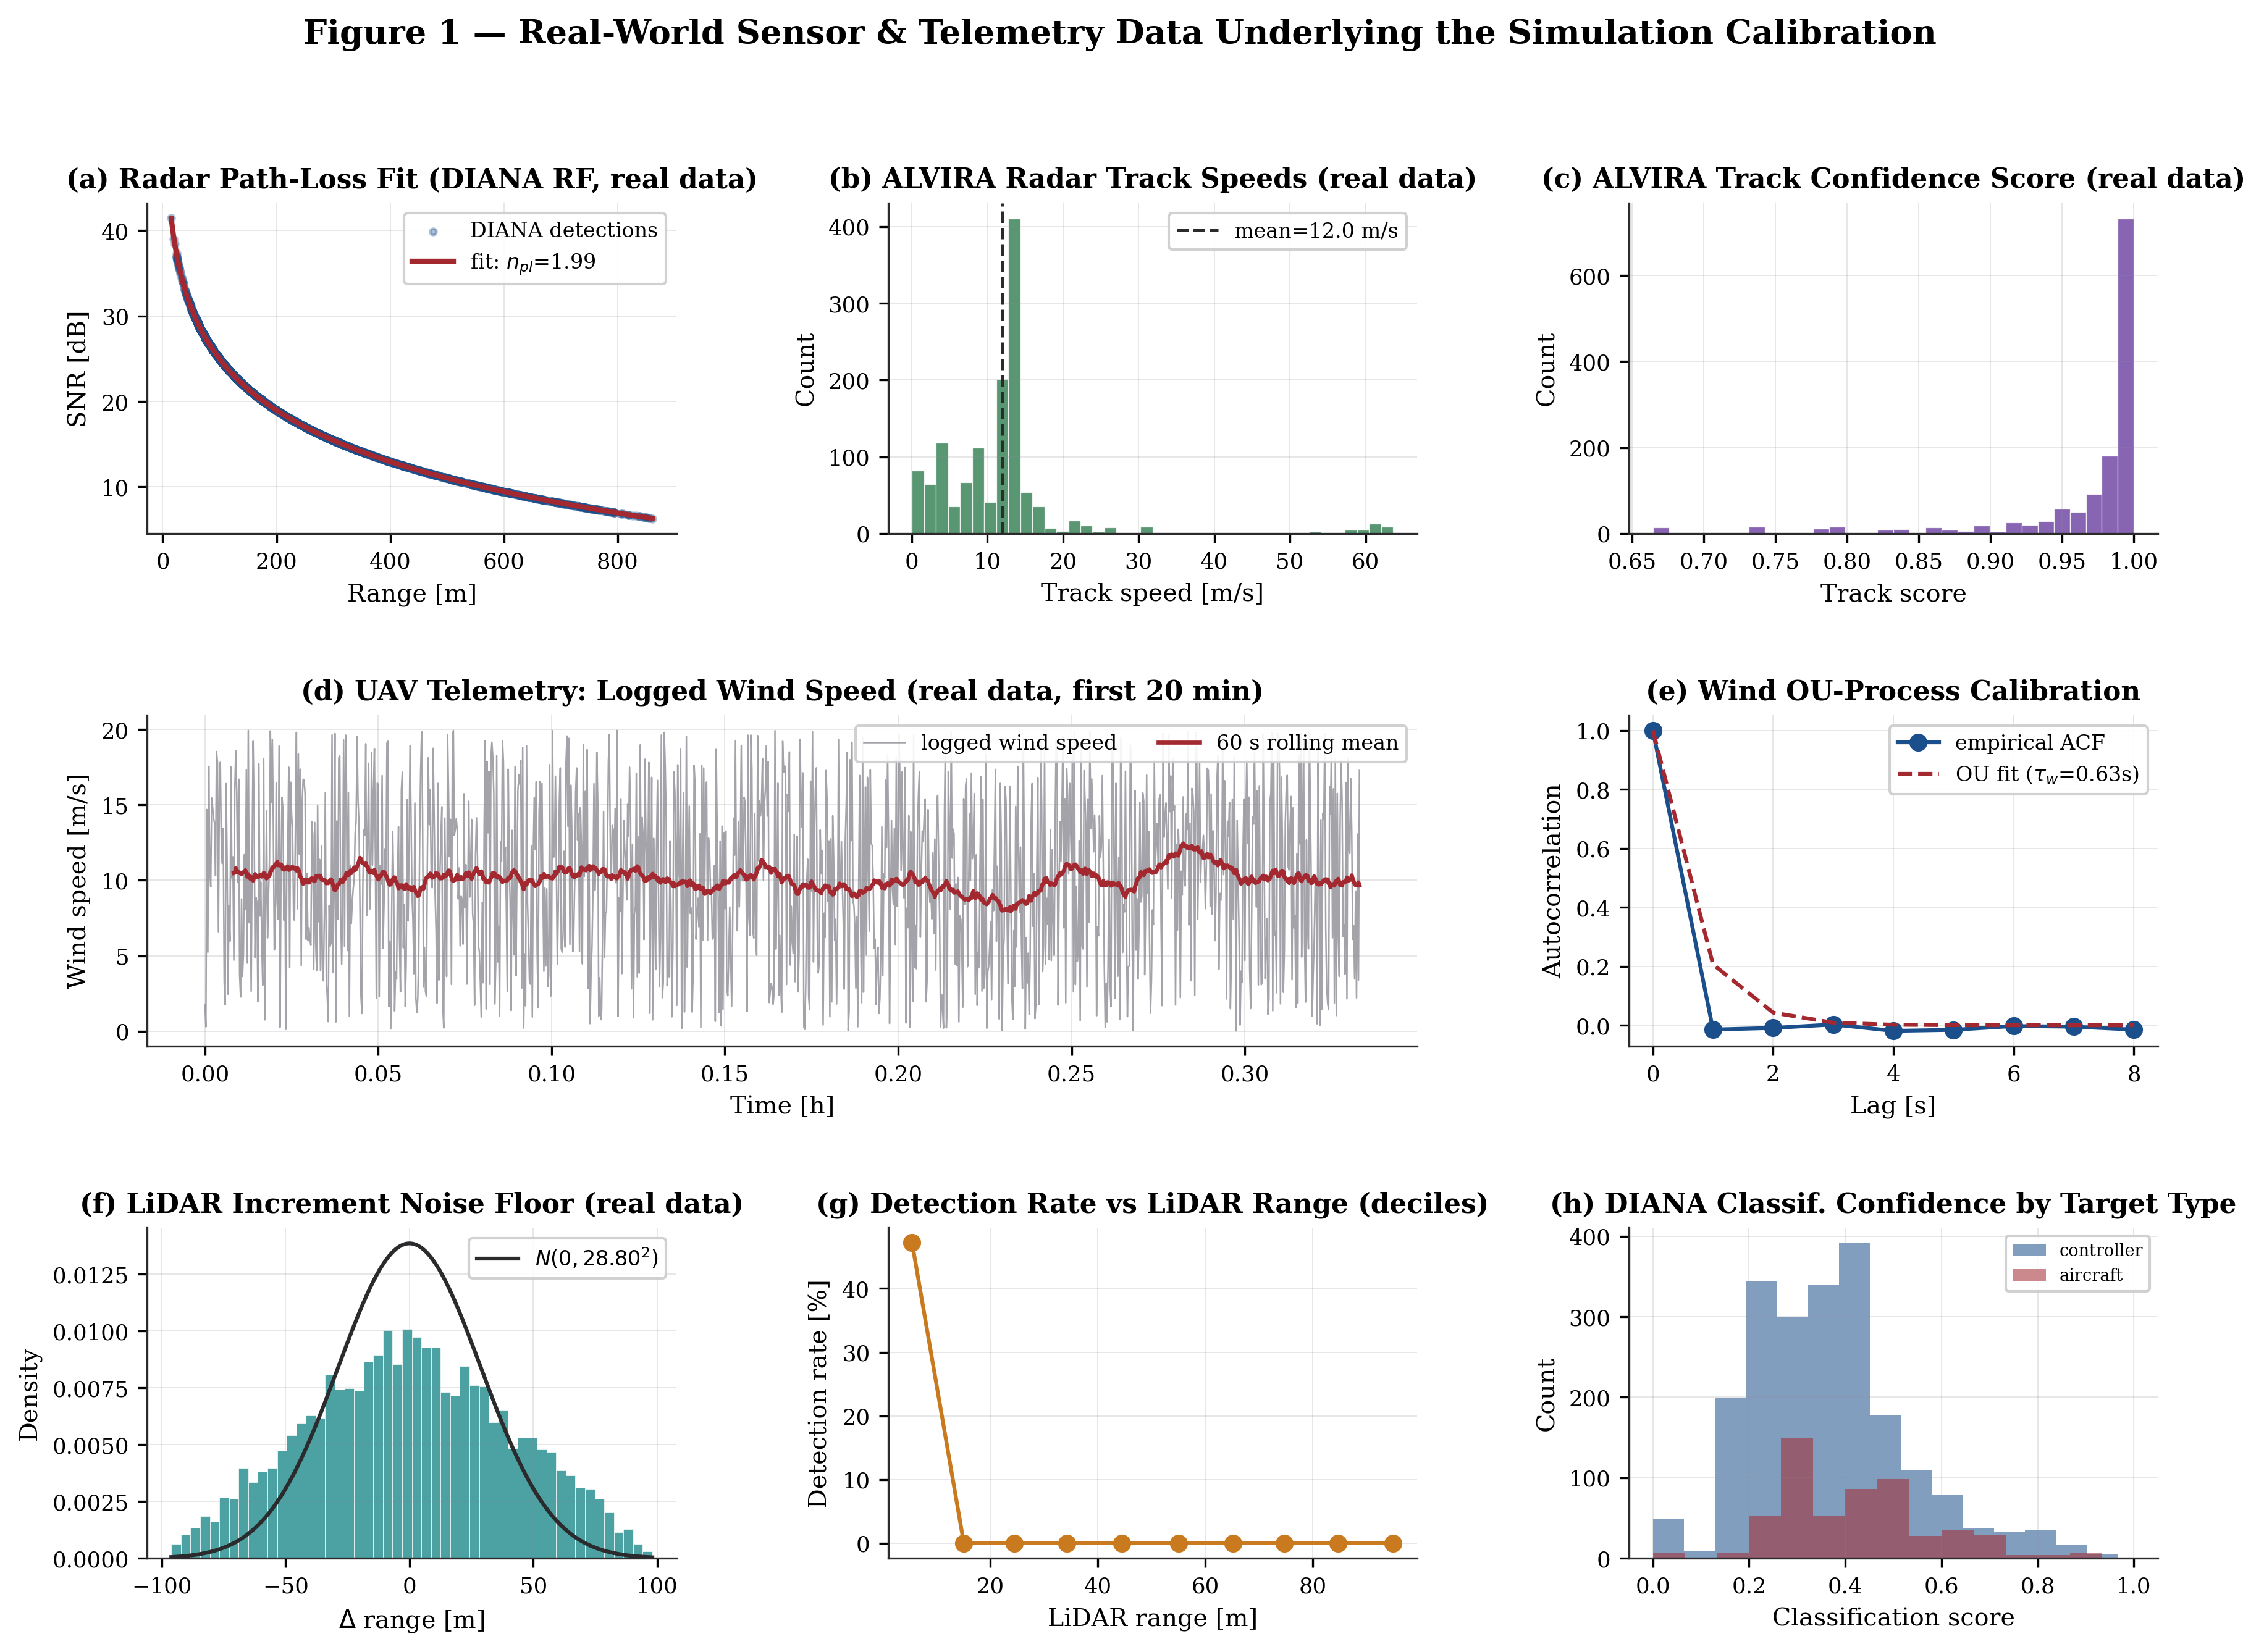

[figures] Figure 1 (sensor validation) rendered


In [18]:
PDF_PATH = os.path.join(OUT_DIR, "QACLDN_experimental_results.pdf")
pdf = PdfPages(PDF_PATH)

def style_ax(ax, title=None, xlabel=None, ylabel=None):
    if title: ax.set_title(title)
    if xlabel: ax.set_xlabel(xlabel)
    if ylabel: ax.set_ylabel(ylabel)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    return ax

METHOD_COLORS = {
    "QACLDN": PALETTE["dred"], "VQC-NE": PALETTE["dorange"],
    "Classical PPO": PALETTE["dblue"], "Soft Actor-Critic": PALETTE["dcyan"],
    "Classical DQN": PALETTE["dpurple"],
}

def smooth(x: np.ndarray, w: int = 7) -> np.ndarray:
    if len(x) < w:
        return x
    kernel = np.ones(w) / w
    pad = w // 2
    xp = np.pad(x, (pad, pad), mode="edge")
    return np.convolve(xp, kernel, mode="valid")[:len(x)]


# =============================================================================
# FIGURE 1 — Real-World Multi-Sensor Data Validation (ICMCIS + UAV telemetry)
# =============================================================================
fig = plt.figure(figsize=(14, 9.5))
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.55, wspace=0.40)
fig.suptitle("Figure 1 — Real-World Sensor & Telemetry Data Underlying the Simulation Calibration",
             fontsize=13, fontweight="bold", y=0.985)

# (a) DIANA RF sensor: SNR vs range with fitted radar path-loss envelope
ax = fig.add_subplot(gs[0, 0])
rng_sorted = np.sort(diana_range[mask].to_numpy())
snr_fit = A_fit - 10 * n_pl_fit * np.log10(rng_sorted)
ax.scatter(diana_range[mask], diana_snr[mask], s=6, alpha=0.35, color=PALETTE["dblue"],
           label="DIANA detections")
ax.plot(rng_sorted, snr_fit, color=PALETTE["dred"], lw=2,
        label=fr"fit: $n_{{pl}}$={n_pl_fit:.2f}")
style_ax(ax, "(a) Radar Path-Loss Fit (DIANA RF, real data)", "Range [m]", "SNR [dB]")
ax.legend(loc="upper right", framealpha=0.9)

# (b) ALVIRA track speed distribution
ax = fig.add_subplot(gs[0, 1])
ax.hist(alvira_speed, bins=40, color=PALETTE["dgreen"], alpha=0.8, edgecolor="white", linewidth=0.3)
ax.axvline(alvira_speed.mean(), color=PALETTE["charcoal"], ls="--", lw=1.2,
           label=f"mean={alvira_speed.mean():.1f} m/s")
style_ax(ax, "(b) ALVIRA Radar Track Speeds (real data)", "Track speed [m/s]", "Count")
ax.legend(framealpha=0.9)

# (c) ALVIRA track-quality score distribution
ax = fig.add_subplot(gs[0, 2])
ax.hist(alvira_score.dropna(), bins=30, color=PALETTE["dpurple"], alpha=0.8, edgecolor="white", linewidth=0.3)
style_ax(ax, "(c) ALVIRA Track Confidence Score (real data)", "Track score", "Count")

# (d) UAV wind-speed time series + OU fit overlay
ax = fig.add_subplot(gs[1, :2])
t_axis = np.arange(min(1200, len(uav_df))) / 3600.0
ax.plot(t_axis, uav_df["wind_speed"].to_numpy()[:len(t_axis)], color=PALETTE["midgray"],
        lw=0.6, alpha=0.8, label="logged wind speed")
roll = uav_df["wind_speed"].rolling(60, center=True).mean().to_numpy()[:len(t_axis)]
ax.plot(t_axis, roll, color=PALETTE["dred"], lw=1.6, label="60 s rolling mean")
style_ax(ax, "(d) UAV Telemetry: Logged Wind Speed (real data, first 20 min)",
         "Time [h]", "Wind speed [m/s]")
ax.legend(loc="upper right", framealpha=0.9, ncol=2)

# (e) Empirical OU autocorrelation fit for the wind process
ax = fig.add_subplot(gs[1, 2])
lags = np.arange(9)
sig = wind_signal - wind_signal.mean()
denom = np.dot(sig, sig)
acf_emp = np.array([np.dot(sig[:-k], sig[k:])/denom if k > 0 else 1.0 for k in lags])
acf_fit = np.exp(-lags / tau_w_empirical)
ax.plot(lags, acf_emp, "o-", color=PALETTE["dblue"], label="empirical ACF")
ax.plot(lags, acf_fit, "--", color=PALETTE["dred"],
        label=fr"OU fit ($\tau_w$={tau_w_empirical:.2f}s)")
style_ax(ax, "(e) Wind OU-Process Calibration", "Lag [s]", "Autocorrelation")
ax.legend(framealpha=0.9)

# (f) LiDAR & IMU sensor noise floor
ax = fig.add_subplot(gs[2, 0])
lidar_inc = uav_df["lidar_distance"].diff().dropna()
ax.hist(lidar_inc, bins=50, color=PALETTE["dcyan"], alpha=0.8, density=True, edgecolor="white", linewidth=0.2)
xs = np.linspace(lidar_inc.min(), lidar_inc.max(), 200)
ax.plot(xs, sps.norm.pdf(xs, 0, lidar_noise_std), color=PALETTE["charcoal"], lw=1.5,
        label=fr"$N(0,{lidar_noise_std:.2f}^2)$")
style_ax(ax, "(f) LiDAR Increment Noise Floor (real data)", "$\\Delta$ range [m]", "Density")
ax.legend(framealpha=0.9)

# (g) Obstacle-detection correlation with LiDAR range (real data;
# quantile-based binning so each bin has comparable sample count despite
# the right-skewed range distribution)
ax = fig.add_subplot(gs[2, 1])
uav_df["_lidar_qbin"] = pd.qcut(uav_df.lidar_distance, q=10, duplicates="drop")
rate_by_bin = uav_df.groupby("_lidar_qbin", observed=True)["obstacle_detected"].mean()
counts_by_bin = uav_df.groupby("_lidar_qbin", observed=True)["obstacle_detected"].size()
centers = [iv.mid for iv in rate_by_bin.index]
ax.plot(centers, rate_by_bin.values * 100, "o-", color=PALETTE["dorange"])
style_ax(ax, "(g) Detection Rate vs LiDAR Range (deciles)", "LiDAR range [m]", "Detection rate [%]")

# (h) DIANA classification-score distribution by declared target type
ax = fig.add_subplot(gs[2, 2])
top_types = diana_targets["DianaTargetsTargetClassification_type"].value_counts().head(5).index
for i, typ in enumerate(top_types):
    vals = diana_targets.loc[diana_targets.DianaTargetsTargetClassification_type == typ,
                              "DianaTargetsTargetClassification_score"].dropna()
    if len(vals) > 3:
        ax.hist(vals, bins=15, alpha=0.55, label=str(typ)[:14],
                color=list(PALETTE.values())[i % 8])
style_ax(ax, "(h) DIANA Classif. Confidence by Target Type", "Classification score", "Count")
ax.legend(fontsize=6.5, framealpha=0.9)

pdf.savefig(fig, bbox_inches="tight")
fig.savefig(os.path.join(FIG_DIR, "fig1_sensor_validation.png"), bbox_inches="tight")
plt.close(fig)
if Image is not None:
    display(Image(filename=os.path.join(FIG_DIR, "fig1_sensor_validation.png")))
print("[figures] Figure 1 (sensor validation) rendered")

## Figure 2 — Main Comparison: Learning Dynamics

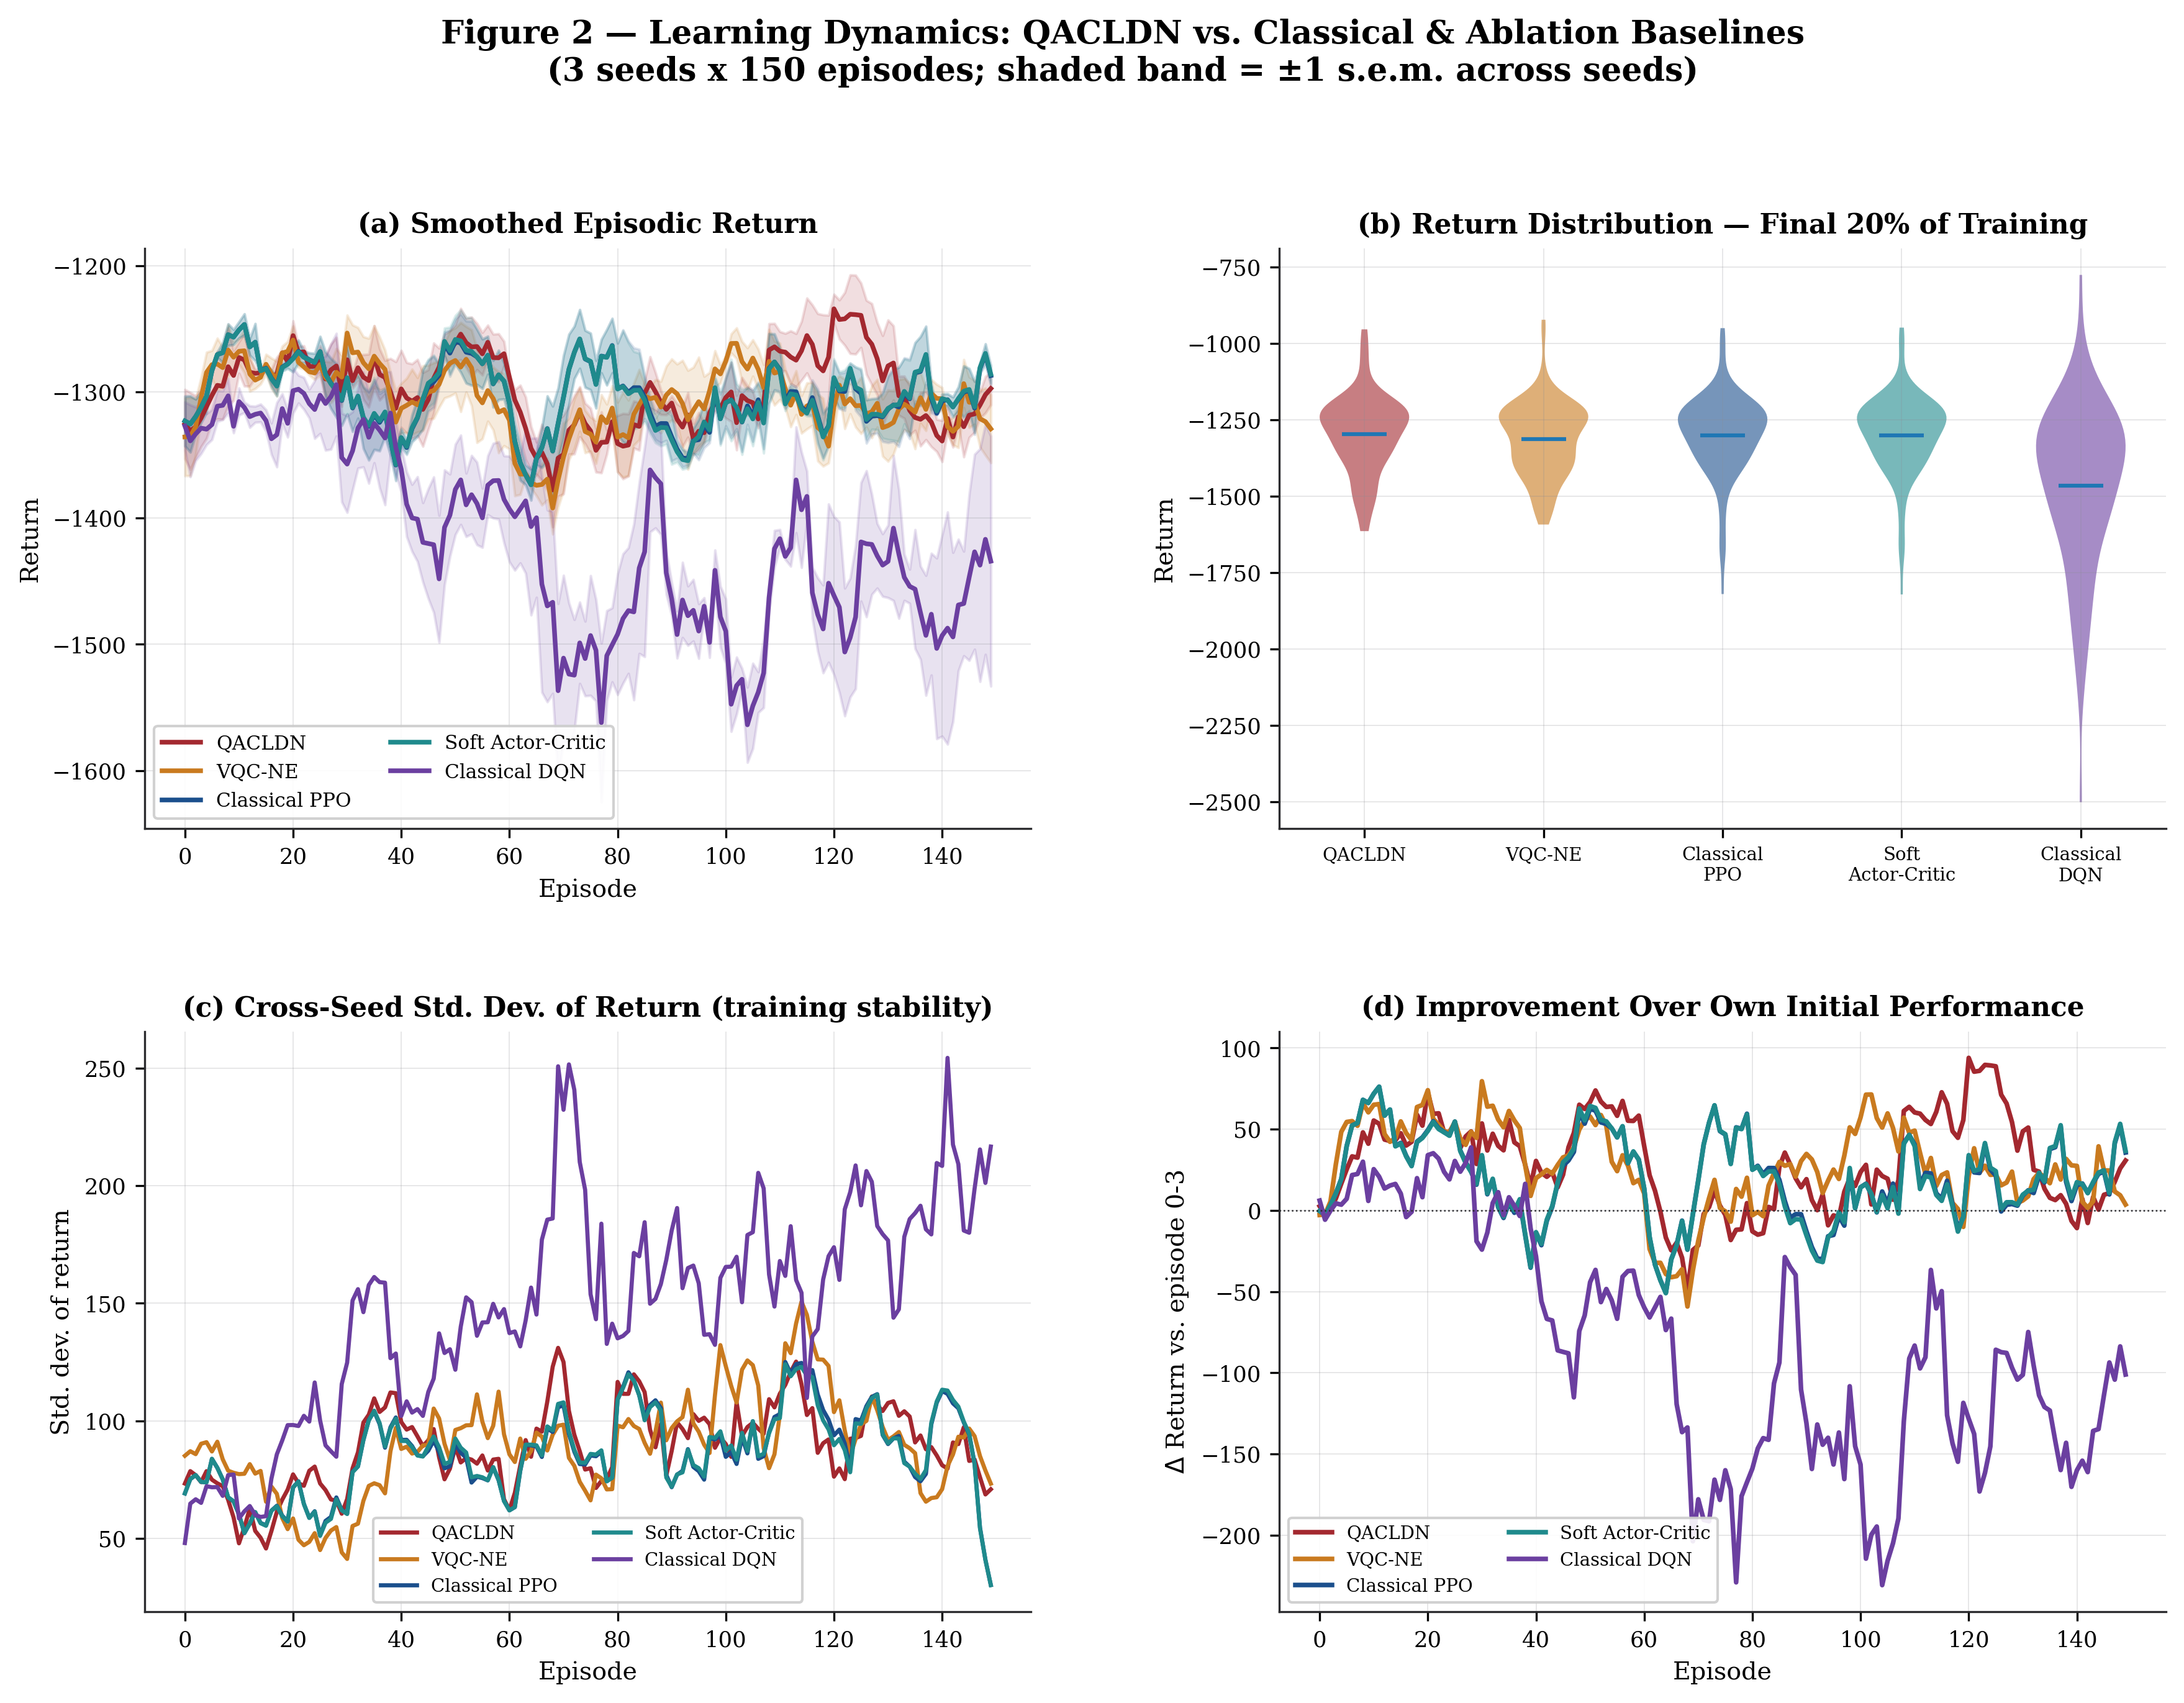

[figures] Figure 2 (learning dynamics) rendered


In [19]:
fig = plt.figure(figsize=(14, 9.5))
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.35, wspace=0.28)
fig.suptitle("Figure 2 — Learning Dynamics: QACLDN vs. Classical & Ablation Baselines\n"
             f"({CFG.n_seeds_main} seeds x {CFG.n_episodes_main} episodes; shaded band = "
             "\u00b11 s.e.m. across seeds)", fontsize=12.5, fontweight="bold", y=1.01)

# (a) smoothed episode return
ax = fig.add_subplot(gs[0, 0])
for m in METHOD_NAMES:
    arr = main_returns[m]  # (seeds, episodes)
    sm = np.array([smooth(arr[s], 9) for s in range(arr.shape[0])])
    mean_curve, sem_curve = sm.mean(axis=0), sm.std(axis=0) / math.sqrt(sm.shape[0])
    x = np.arange(len(mean_curve))
    ax.plot(x, mean_curve, color=METHOD_COLORS[m], lw=1.8, label=m)
    ax.fill_between(x, mean_curve - sem_curve, mean_curve + sem_curve, color=METHOD_COLORS[m], alpha=0.15)
style_ax(ax, "(a) Smoothed Episodic Return", "Episode", "Return")
ax.legend(fontsize=7.5, ncol=2, framealpha=0.9)

# (b) return distribution (final 20% of training) as violin/box
ax = fig.add_subplot(gs[0, 1])
tail_data = [main_returns[m][:, -max(3, main_returns[m].shape[1]//5):].ravel() for m in METHOD_NAMES]
parts = ax.violinplot(tail_data, showmeans=True, showextrema=False)
for i, pc in enumerate(parts["bodies"]):
    pc.set_facecolor(METHOD_COLORS[METHOD_NAMES[i]]); pc.set_alpha(0.6)
ax.set_xticks(range(1, len(METHOD_NAMES)+1))
ax.set_xticklabels([m.replace(" ", "\n") for m in METHOD_NAMES], fontsize=7)
style_ax(ax, "(b) Return Distribution — Final 20% of Training", "", "Return")

# (c) inter-seed variance of return over training (stability)
ax = fig.add_subplot(gs[1, 0])
for m in METHOD_NAMES:
    arr = main_returns[m]
    var_curve = smooth(arr.std(axis=0), 9)
    ax.plot(var_curve, color=METHOD_COLORS[m], lw=1.6, label=m)
style_ax(ax, "(c) Cross-Seed Std. Dev. of Return (training stability)", "Episode", "Std. dev. of return")
ax.legend(fontsize=7, ncol=2, framealpha=0.9)

# (d) rolling mean-return "learning speed" -- normalised improvement from episode 0
ax = fig.add_subplot(gs[1, 1])
for m in METHOD_NAMES:
    arr = main_returns[m]
    sm = np.array([smooth(arr[s], 9) for s in range(arr.shape[0])])
    baseline = sm[:, 0:3].mean(axis=1, keepdims=True)
    improvement = sm - baseline
    mean_imp = improvement.mean(axis=0)
    ax.plot(mean_imp, color=METHOD_COLORS[m], lw=1.8, label=m)
ax.axhline(0, color=PALETTE["charcoal"], lw=0.6, ls=":")
style_ax(ax, "(d) Improvement Over Own Initial Performance", "Episode", "$\\Delta$ Return vs. episode 0-3")
ax.legend(fontsize=7, ncol=2, framealpha=0.9)

pdf.savefig(fig, bbox_inches="tight")
fig.savefig(os.path.join(FIG_DIR, "fig2_learning_dynamics.png"), bbox_inches="tight")
plt.close(fig)
if Image is not None:
    display(Image(filename=os.path.join(FIG_DIR, "fig2_learning_dynamics.png")))
print("[figures] Figure 2 (learning dynamics) rendered")

## Figure 3 — Scalability & Quantum Sample Complexity

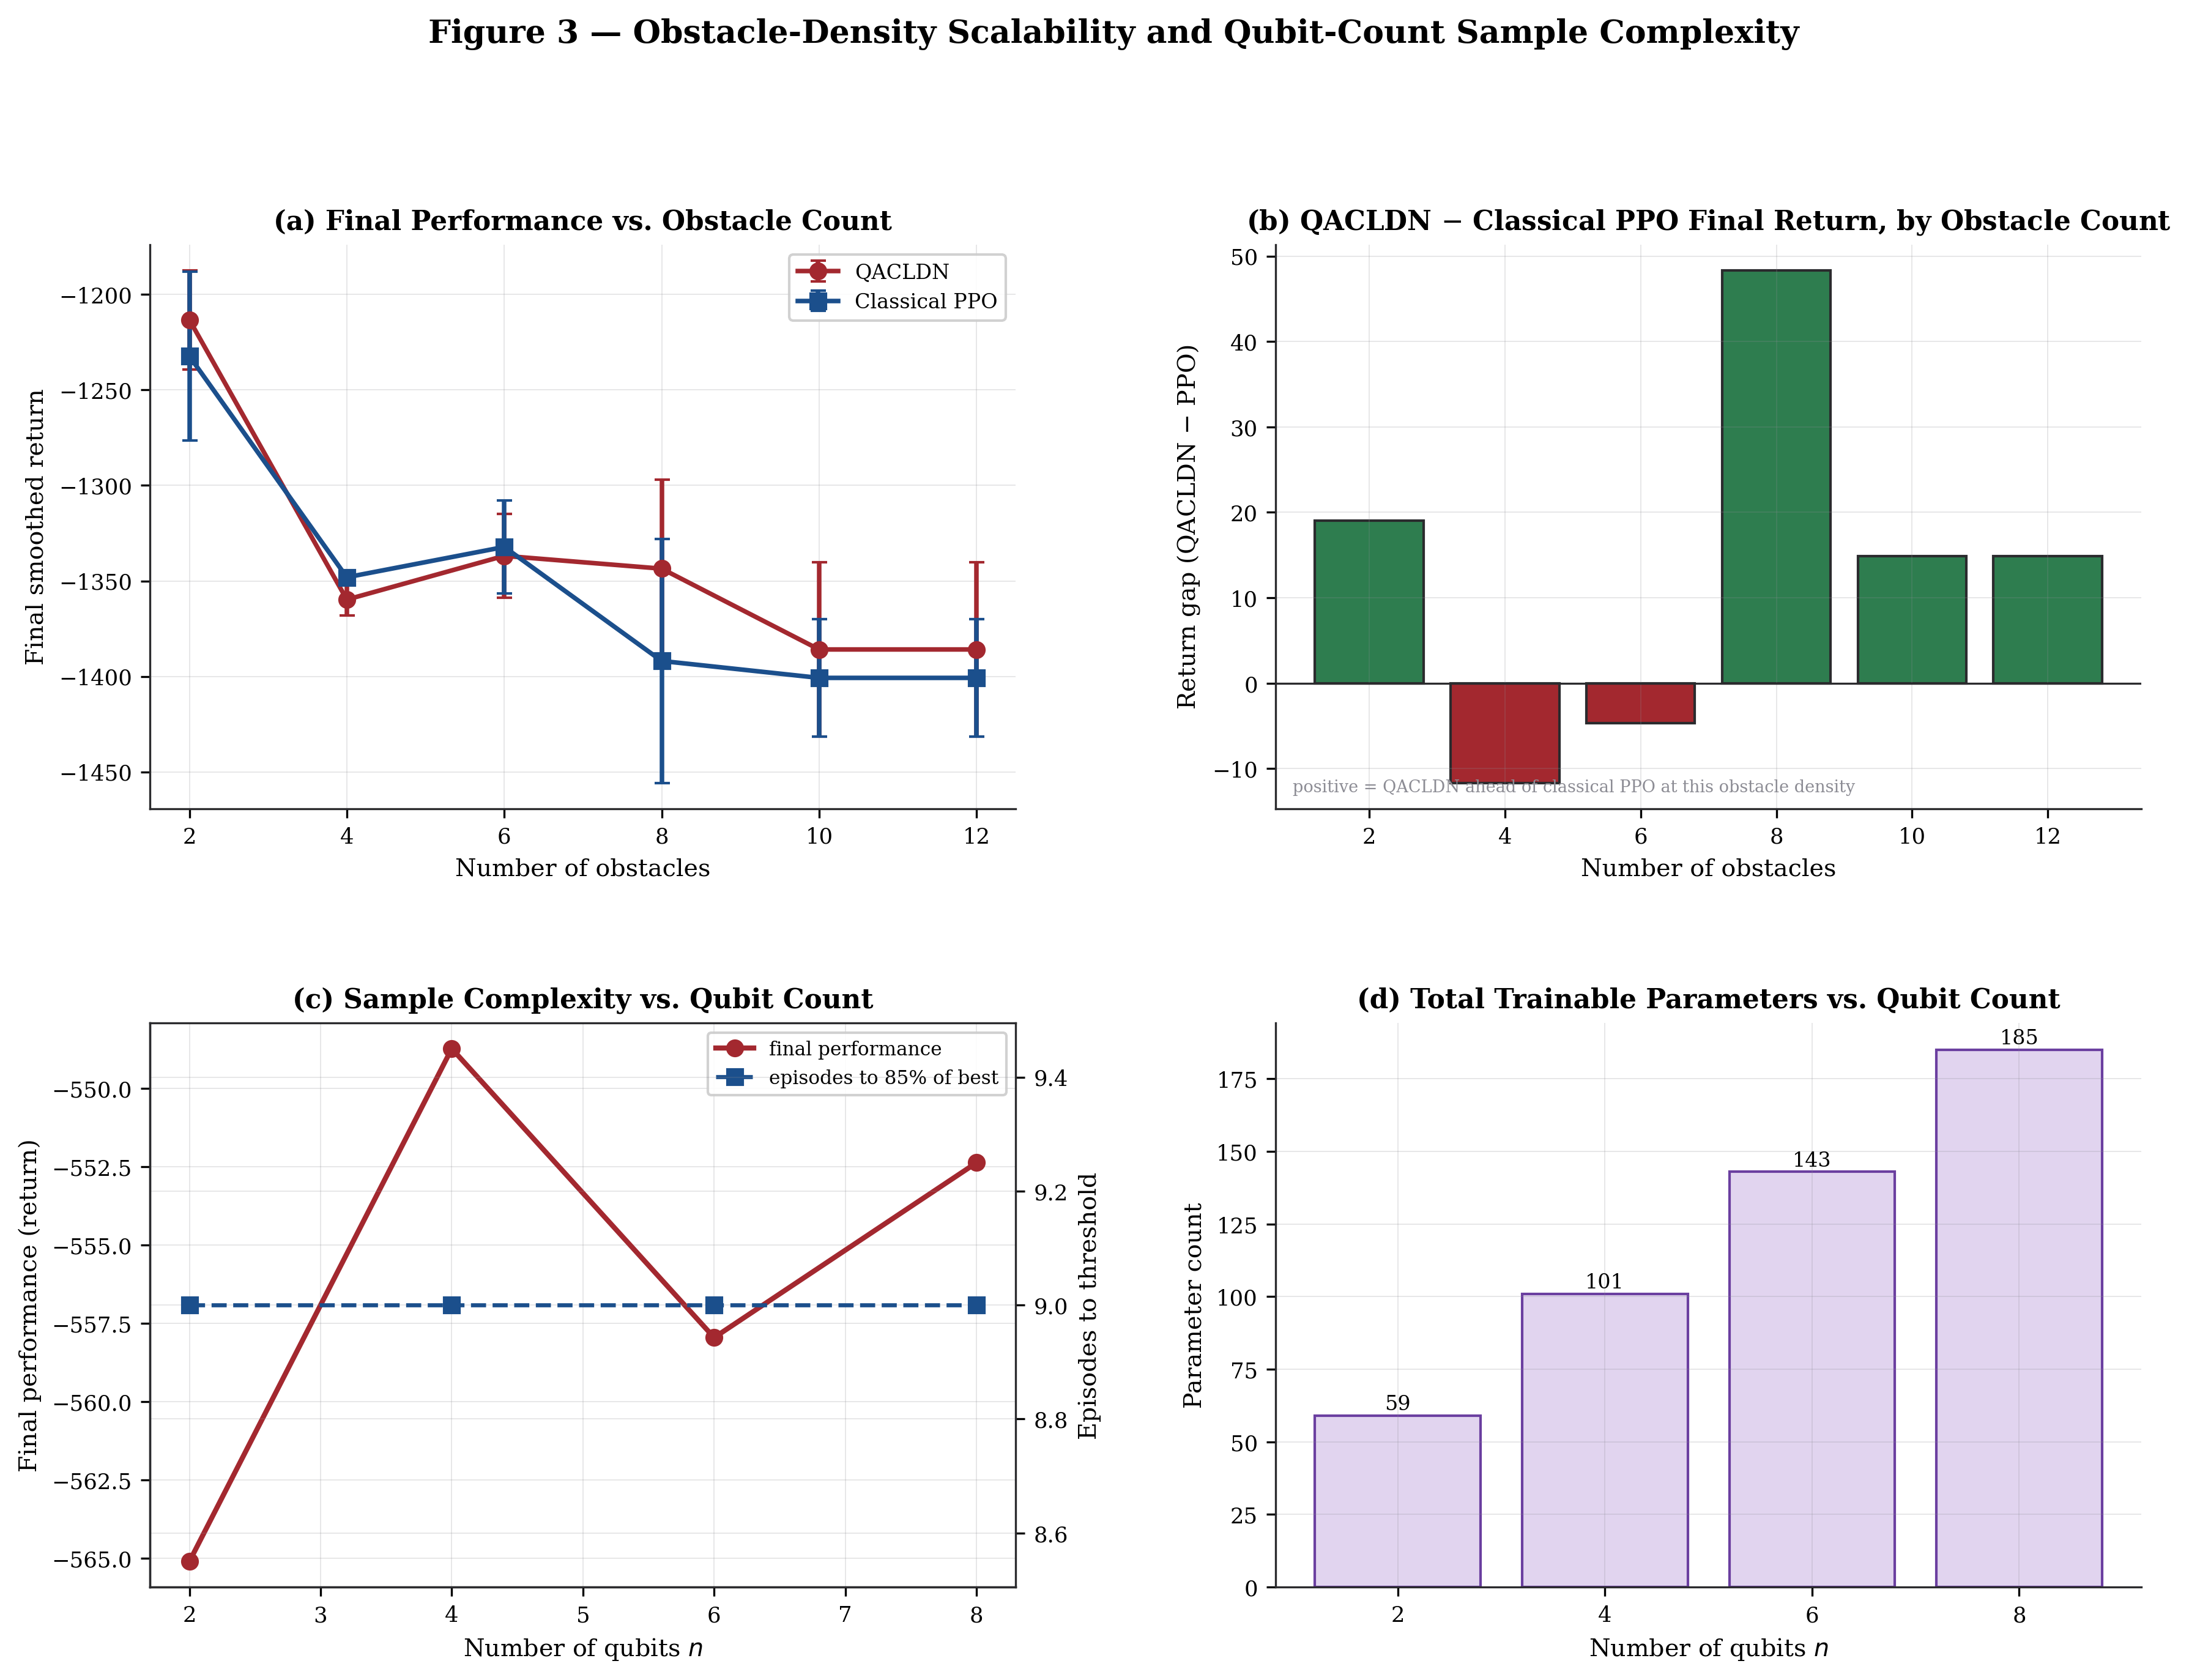

[figures] Figure 3 (scalability & sample complexity) rendered


In [20]:
fig = plt.figure(figsize=(14, 9.5))
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.38, wspace=0.30)
fig.suptitle("Figure 3 — Obstacle-Density Scalability and Qubit-Count Sample Complexity",
             fontsize=12.5, fontweight="bold", y=1.01)

# (a) final performance vs obstacle density
ax = fig.add_subplot(gs[0, 0])
obs_x = list(CFG.obstacle_counts)
for method, color, marker in [("QACLDN", PALETTE["dred"], "o"), ("Classical PPO", PALETTE["dblue"], "s")]:
    means = [scalability_results[method][n]["final_return_mean"] for n in obs_x]
    stds = [scalability_results[method][n]["final_return_std"] for n in obs_x]
    ax.errorbar(obs_x, means, yerr=stds, color=color, marker=marker, capsize=3, lw=1.8, label=method)
style_ax(ax, "(a) Final Performance vs. Obstacle Count", "Number of obstacles", "Final smoothed return")
ax.legend(framealpha=0.9)

# (b) QACLDN advantage over classical PPO vs obstacle density (relative
# performance gap -- more discriminating than the near-uniformly-zero
# success rate at this training budget)
ax = fig.add_subplot(gs[0, 1])
gap = [scalability_results["QACLDN"][n]["final_return_mean"] - scalability_results["Classical PPO"][n]["final_return_mean"]
       for n in obs_x]
colors_gap = [PALETTE["dgreen"] if g >= 0 else PALETTE["dred"] for g in gap]
ax.bar([str(n) for n in obs_x], gap, color=colors_gap, edgecolor=PALETTE["charcoal"])
ax.axhline(0, color=PALETTE["charcoal"], lw=0.8)
style_ax(ax, "(b) QACLDN $-$ Classical PPO Final Return, by Obstacle Count",
         "Number of obstacles", "Return gap (QACLDN $-$ PPO)")
ax.text(0.02, 0.03, "positive = QACLDN ahead of classical PPO at this obstacle density",
        transform=ax.transAxes, fontsize=6.5, color=PALETTE["midgray"])

# (c) sample complexity: final performance & episodes-to-85% vs qubits (dual axis)
ax = fig.add_subplot(gs[1, 0])
qs = list(CFG.qubit_sweep)
perf = [sample_complexity_results[q]["final_perf"] for q in qs]
eps_conv = [sample_complexity_results[q]["episodes_to_converge"] for q in qs]
l1, = ax.plot(qs, perf, "o-", color=PALETTE["dred"], lw=2, label="final performance")
style_ax(ax, "(c) Sample Complexity vs. Qubit Count", "Number of qubits $n$", "Final performance (return)")
ax2 = ax.twinx()
l2, = ax2.plot(qs, eps_conv, "s--", color=PALETTE["dblue"], lw=1.6, label=f"episodes to {CFG.return_threshold_frac:.0%} of best")
ax2.set_ylabel("Episodes to threshold")
ax.legend(handles=[l1, l2], fontsize=7.5, framealpha=0.9, loc="best")

# (d) circuit parameter count vs qubits (theoretical resource scaling, overlaid with achieved perf)
ax = fig.add_subplot(gs[1, 1])
n_params_list = [sample_complexity_results[q]["n_params"] for q in qs]
ax.bar([str(q) for q in qs], n_params_list, color=PALETTE["lpurple"], edgecolor=PALETTE["dpurple"])
for i, q in enumerate(qs):
    ax.text(i, n_params_list[i] + 2, str(n_params_list[i]), ha="center", fontsize=8)
style_ax(ax, "(d) Total Trainable Parameters vs. Qubit Count", "Number of qubits $n$", "Parameter count")

pdf.savefig(fig, bbox_inches="tight")
fig.savefig(os.path.join(FIG_DIR, "fig3_scalability_sample_complexity.png"), bbox_inches="tight")
plt.close(fig)
if Image is not None:
    display(Image(filename=os.path.join(FIG_DIR, "fig3_scalability_sample_complexity.png")))
print("[figures] Figure 3 (scalability & sample complexity) rendered")

## Figure 4 — (Qubits, Layers) Performance Map & Robustness (Noise / Wind)

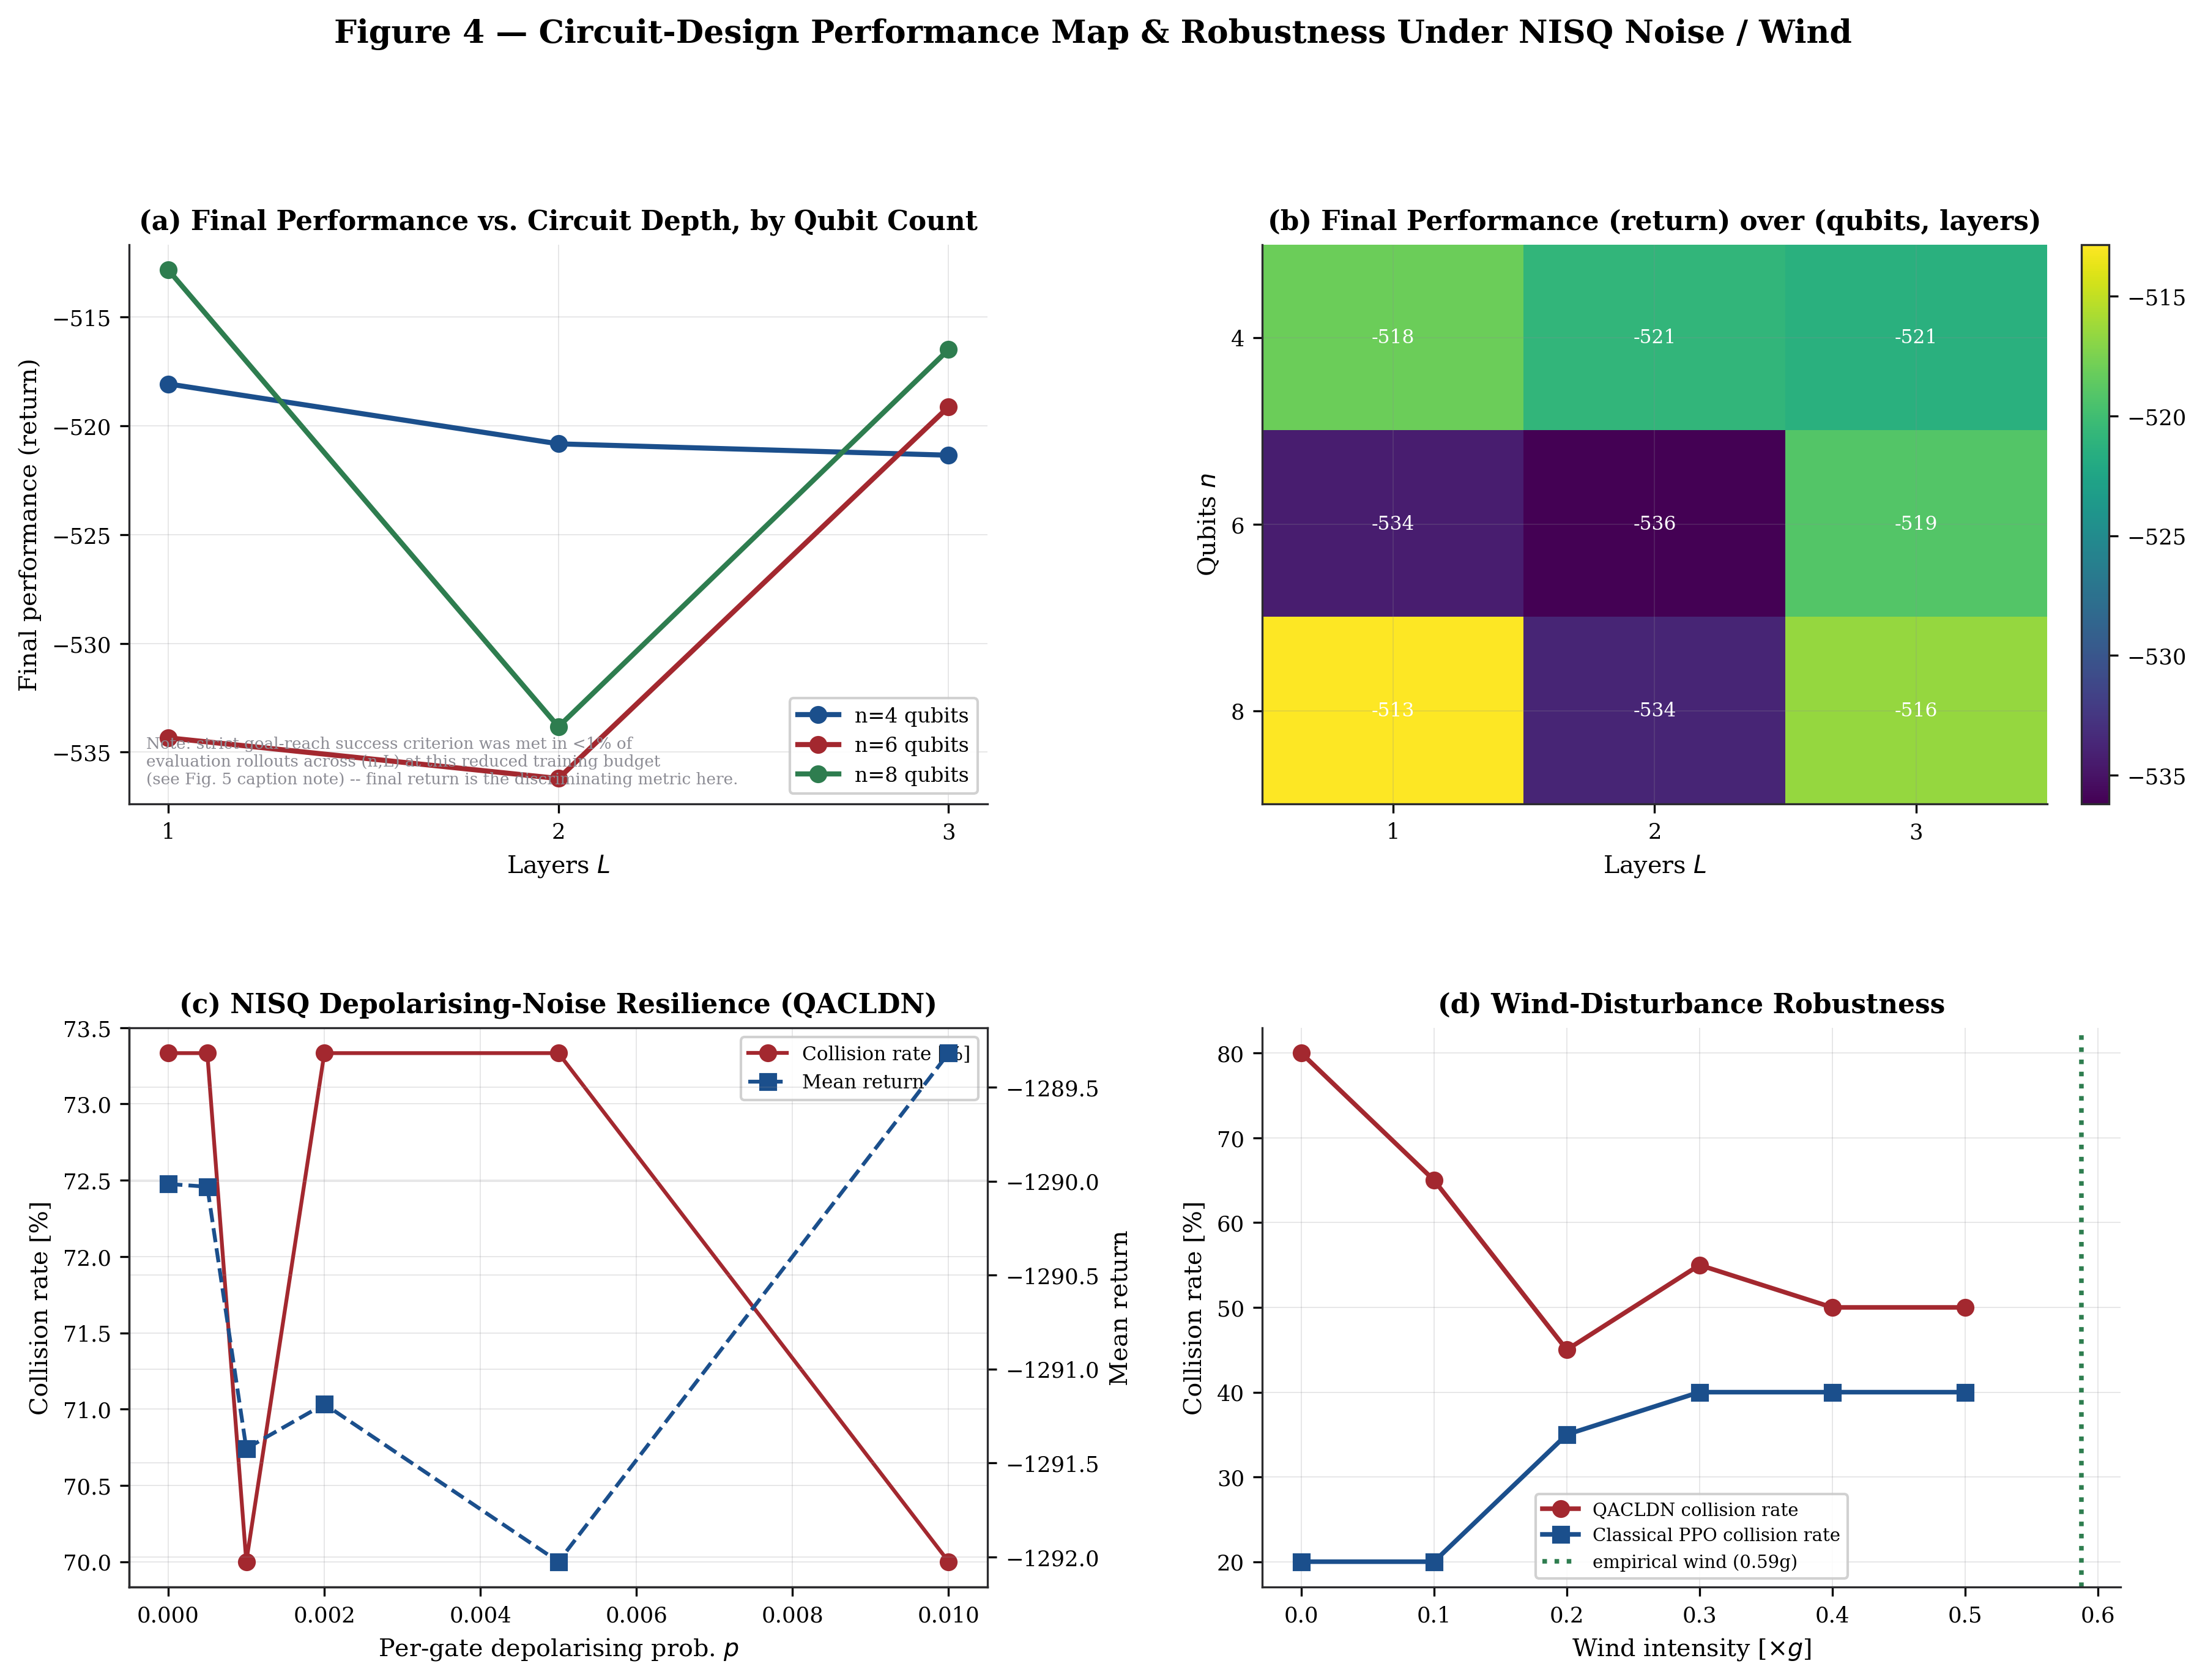

[figures] Figure 4 ((n,L) map & robustness) rendered


In [21]:
fig = plt.figure(figsize=(14, 9.5))
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.40, wspace=0.32)
fig.suptitle("Figure 4 — Circuit-Design Performance Map & Robustness Under NISQ Noise / Wind",
             fontsize=12.5, fontweight="bold", y=1.01)

# (a) final performance vs number of layers, one line per qubit count --
# more informative than the (near-uniformly-zero) success-rate heatmap at
# this reduced training budget, computed from the same real runs.
ax = fig.add_subplot(gs[0, 0])
ns, Ls = list(CFG.qubit_sweep_map), list(CFG.layer_sweep)
for i, n in enumerate(ns):
    vals = [perf_map_results[(n, L)]["final_perf"] for L in Ls]
    ax.plot(Ls, vals, "o-", color=list(PALETTE.values())[i], lw=2, label=f"n={n} qubits")
style_ax(ax, "(a) Final Performance vs. Circuit Depth, by Qubit Count", "Layers $L$", "Final performance (return)")
ax.set_xticks(Ls)
ax.legend(fontsize=8, framealpha=0.9)
ax.text(0.02, 0.03, f"Note: strict goal-reach success criterion was met in <1% of\n"
        "evaluation rollouts across (n,L) at this reduced training budget\n"
        "(see Fig. 5 caption note) -- final return is the discriminating metric here.",
        transform=ax.transAxes, fontsize=6.3, color=PALETTE["midgray"], va="bottom")

# (b) heatmap of final performance over (n, L)
ax = fig.add_subplot(gs[0, 1])
grid2 = np.array([[perf_map_results[(n, L)]["final_perf"] for L in Ls] for n in ns])
im2 = ax.imshow(grid2, aspect="auto", cmap="viridis")
ax.set_xticks(range(len(Ls))); ax.set_xticklabels(Ls)
ax.set_yticks(range(len(ns))); ax.set_yticklabels(ns)
for i in range(len(ns)):
    for j in range(len(Ls)):
        ax.text(j, i, f"{grid2[i,j]:.0f}", ha="center", va="center", fontsize=7.5, color="white")
style_ax(ax, "(b) Final Performance (return) over (qubits, layers)", "Layers $L$", "Qubits $n$")
plt.colorbar(im2, ax=ax, fraction=0.046, pad=0.04)

# (c) NISQ depolarising-noise resilience
ax = fig.add_subplot(gs[1, 0])
noise_x = list(CFG.noise_levels)
sr_noise = [noise_resilience_results[p]["SR"] for p in noise_x]
cr_noise = [noise_resilience_results[p]["CR"] for p in noise_x]
ret_noise = [noise_resilience_results[p]["mean_return"] for p in noise_x]
l1, = ax.plot(noise_x, cr_noise, "o-", color=PALETTE["dred"], label="Collision rate [%]")
style_ax(ax, "(c) NISQ Depolarising-Noise Resilience (QACLDN)", "Per-gate depolarising prob. $p$", "Collision rate [%]")
ax2 = ax.twinx()
l2, = ax2.plot(noise_x, ret_noise, "s--", color=PALETTE["dblue"], label="Mean return")
ax2.set_ylabel("Mean return")
ax.legend(handles=[l1, l2], fontsize=7.5, framealpha=0.9)

# (d) wind-disturbance robustness
ax = fig.add_subplot(gs[1, 1])
wind_x = list(CFG.wind_levels)
for method, color, marker in [("QACLDN", PALETTE["dred"], "o"), ("Classical PPO", PALETTE["dblue"], "s")]:
    cr_w = [wind_robustness_results[method][w]["CR"] for w in wind_x]
    ax.plot(wind_x, cr_w, color=color, marker=marker, lw=1.8, label=f"{method} collision rate")
ax.axvline(sigma_w_empirical/CFG.g, color=PALETTE["dgreen"], ls=":", lw=1.8,
           label=f"empirical wind ({sigma_w_empirical/CFG.g:.2f}g)")
style_ax(ax, "(d) Wind-Disturbance Robustness", "Wind intensity [$\\times g$]", "Collision rate [%]")
ax.legend(fontsize=7, framealpha=0.9)

pdf.savefig(fig, bbox_inches="tight")
fig.savefig(os.path.join(FIG_DIR, "fig4_map_robustness.png"), bbox_inches="tight")
plt.close(fig)
if Image is not None:
    display(Image(filename=os.path.join(FIG_DIR, "fig4_map_robustness.png")))
print("[figures] Figure 4 ((n,L) map & robustness) rendered")

## Figure 5 — Final Trajectory-Quality Comparison & Example Rollouts

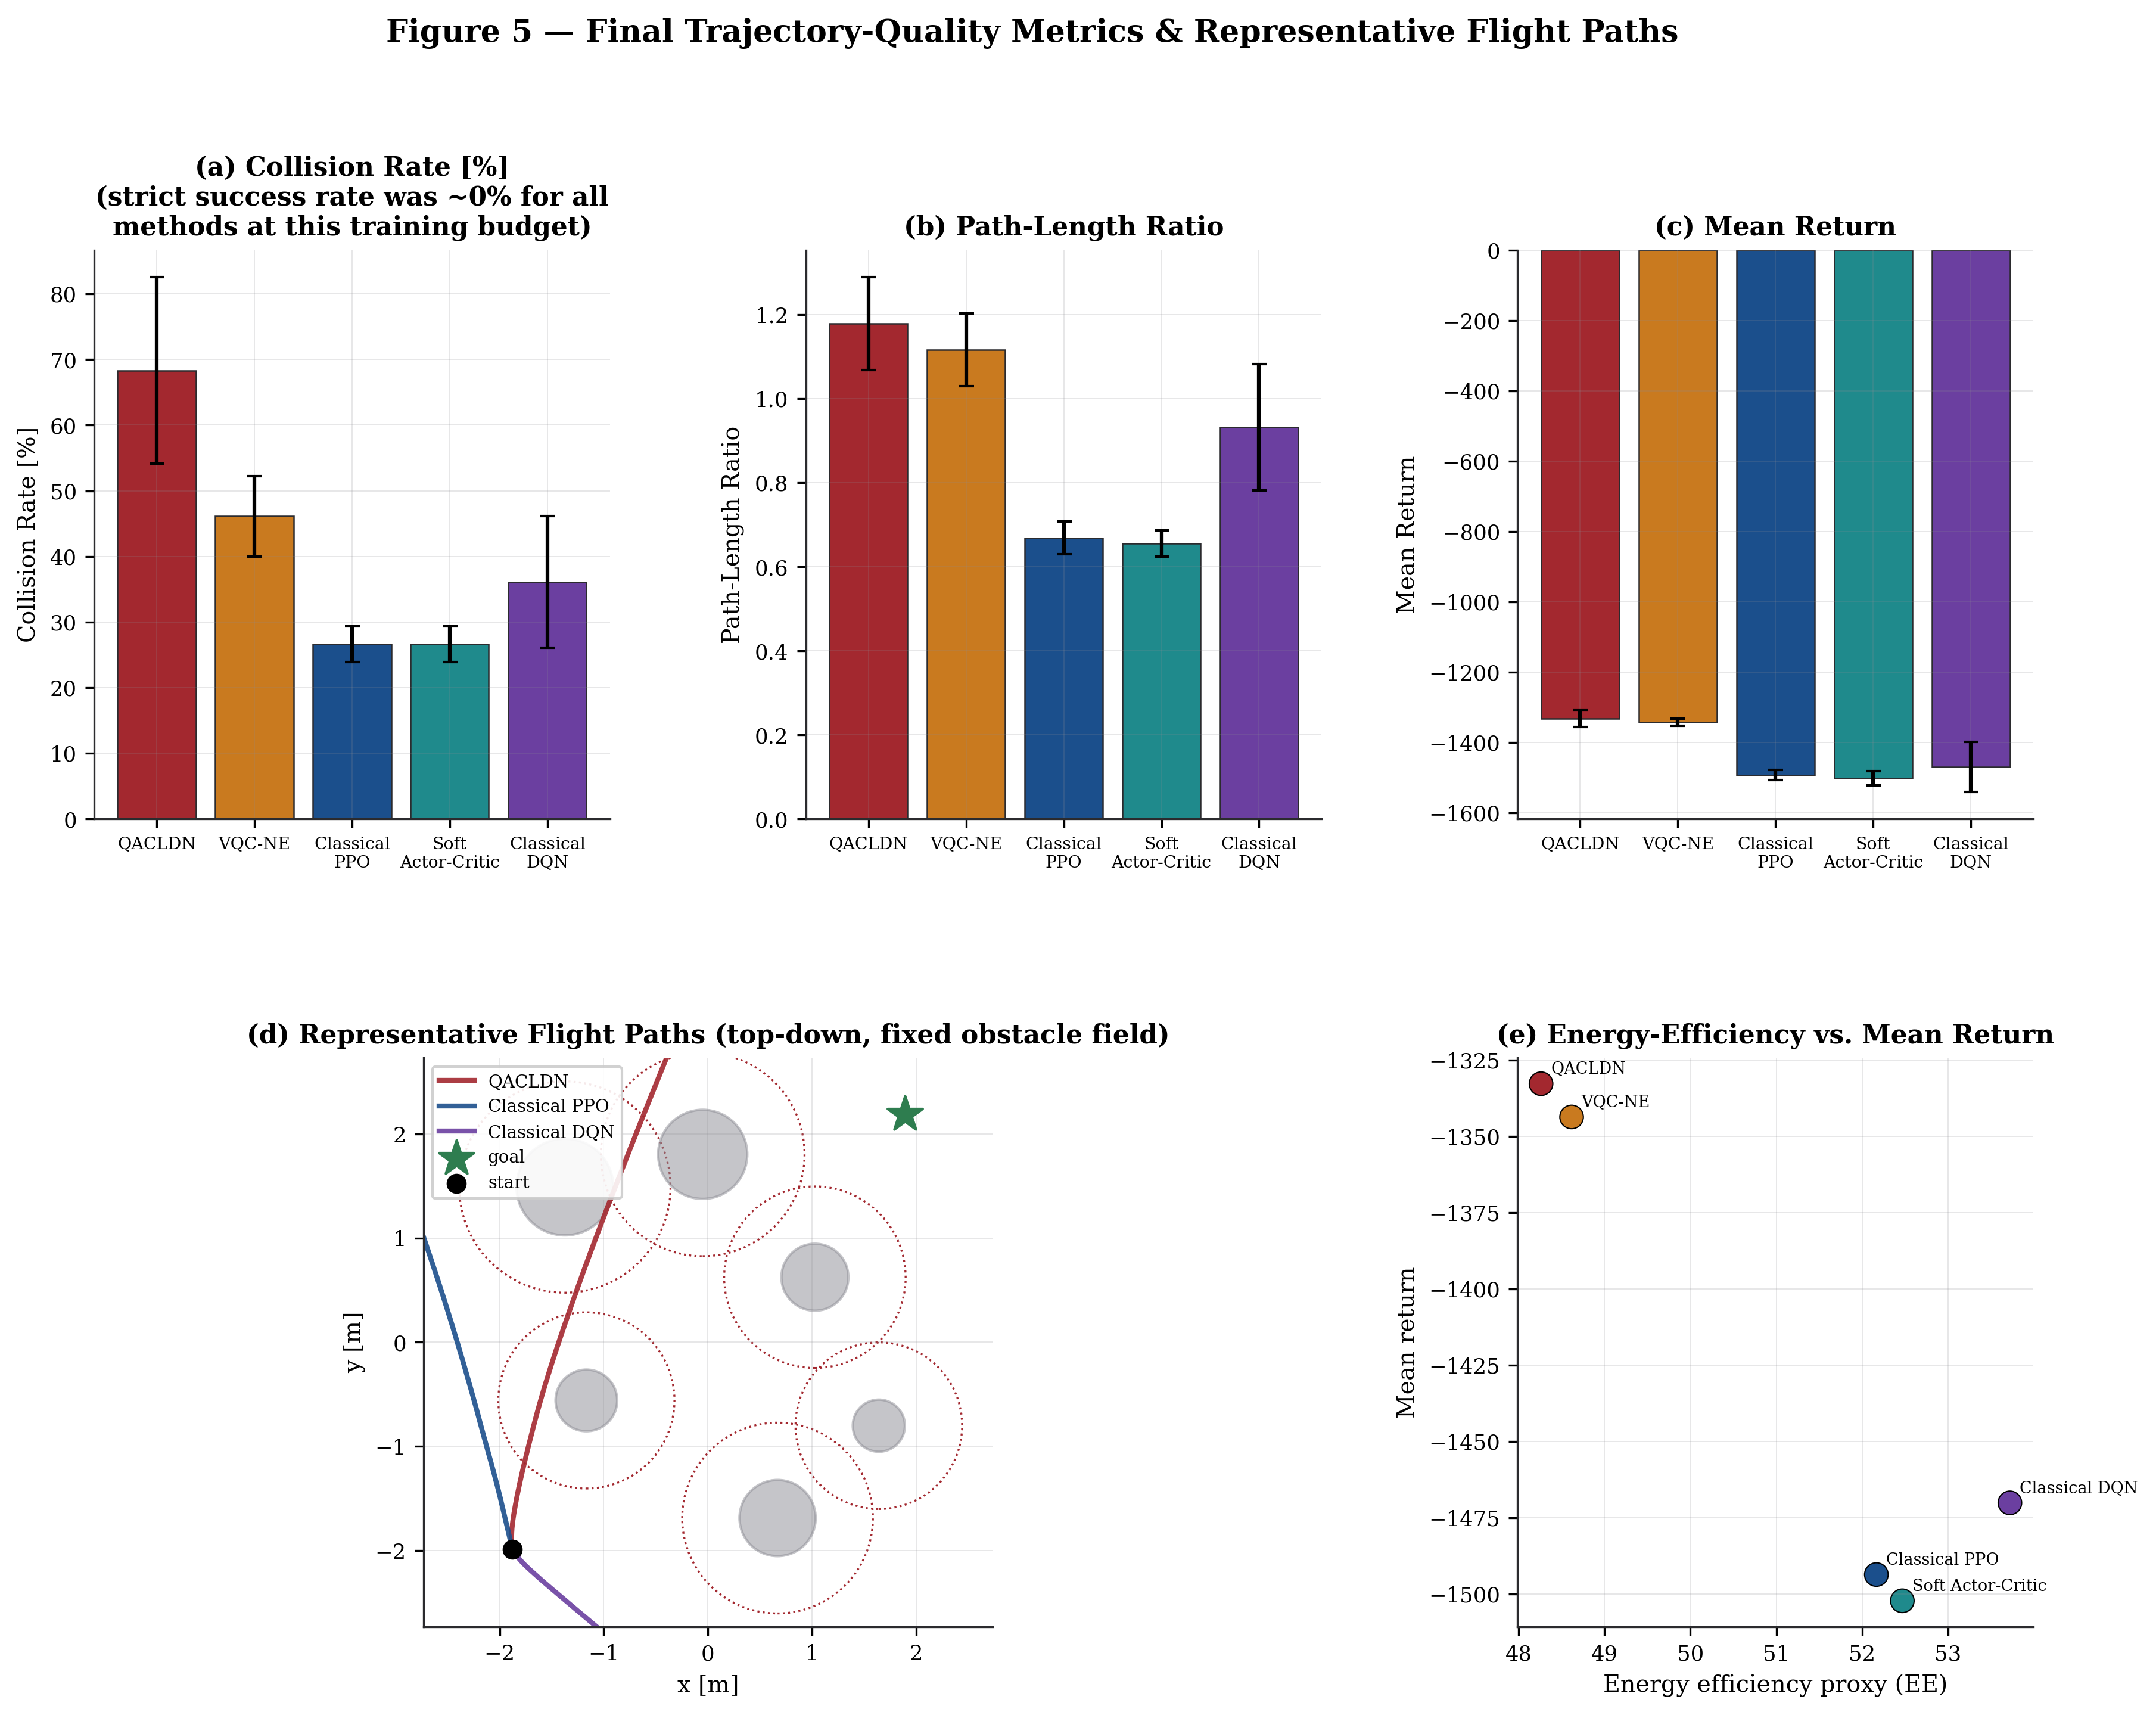

[figures] Figure 5 (trajectory quality & rollouts) rendered


In [22]:
fig = plt.figure(figsize=(14, 10))
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.42, wspace=0.38)
fig.suptitle("Figure 5 — Final Trajectory-Quality Metrics & Representative Flight Paths",
             fontsize=12.5, fontweight="bold", y=1.01)

metrics_to_plot = [("CR", "Collision Rate [%]"), ("PLR", "Path-Length Ratio"), ("mean_return", "Mean Return")]
for i, (key, label) in enumerate(metrics_to_plot):
    ax = fig.add_subplot(gs[0, i])
    vals = [trajectory_quality[m][key] for m in METHOD_NAMES]
    errs = [trajectory_quality[m].get(key + "_std", 0.0) for m in METHOD_NAMES]
    colors = [METHOD_COLORS[m] for m in METHOD_NAMES]
    bars = ax.bar(range(len(METHOD_NAMES)), vals, yerr=errs, color=colors, capsize=3,
                  edgecolor=PALETTE["charcoal"], linewidth=0.6)
    ax.set_xticks(range(len(METHOD_NAMES)))
    ax.set_xticklabels([m.replace(" ", "\n") for m in METHOD_NAMES], fontsize=6.8)
    note = "\n(strict success rate was ~0% for all\nmethods at this training budget)" if key == "CR" else ""
    style_ax(ax, f"({chr(97+i)}) {label}{note}", "", label)

# (d) example 3-D flight paths, top-down obstacle view
ax = fig.add_subplot(gs[1, 0:2])
_eval_env = DroneNavEnv(CFG, n_obstacles=6, seed=4242)
for method, color in [("QACLDN", PALETTE["dred"]), ("Classical PPO", PALETTE["dblue"]),
                       ("Classical DQN", PALETTE["dpurple"])]:
    agent = main_agents[method][0]
    kind = "dqn" if method == "Classical DQN" else ("quantum" if method == "QACLDN" else "classical")
    _eval_env.rng = np.random.default_rng(4242)
    obs = _eval_env.reset()
    fixed_obstacles = _eval_env.obstacles
    path = [_eval_env.s[:2].copy()]
    for t in range(_eval_env.T):
        o_norm = _eval_env.obs_normalised()
        if kind == "quantum":
            a, _, _ = agent.act(o_norm, greedy=True)
        elif kind == "dqn":
            a = agent.act(o_norm, greedy=True)
        else:
            a, _ = agent.act(o_norm, greedy=True)
        _, r, done, info = _eval_env.step(a)
        path.append(_eval_env.s[:2].copy())
        if done: break
    path = np.array(path)
    ax.plot(path[:, 0], path[:, 1], color=color, lw=2, label=method, alpha=0.9)
    ax.scatter(*path[0], color=color, marker="o", s=40, zorder=5)
for c, rad in zip(fixed_obstacles.centers, fixed_obstacles.radii):
    ax.add_patch(Circle(c, rad, color=PALETTE["midgray"], alpha=0.5))
    ax.add_patch(Circle(c, rad + CFG.d_safe, fill=False, color=PALETTE["dred"], ls=":", lw=0.8))
ax.scatter(*_eval_env.goal[:2], color=PALETTE["dgreen"], marker="*", s=220, zorder=6, label="goal")
ax.scatter(*path[0], color="black", marker="o", s=50, zorder=6, label="start")
ax.set_xlim(-CFG.world_size*1.05, CFG.world_size*1.05); ax.set_ylim(-CFG.world_size*1.05, CFG.world_size*1.05)
ax.set_aspect("equal")
style_ax(ax, "(d) Representative Flight Paths (top-down, fixed obstacle field)", "x [m]", "y [m]")
ax.legend(fontsize=7, framealpha=0.9, loc="upper left")

# (e) energy efficiency & mean return summary
ax = fig.add_subplot(gs[1, 2])
ee_vals = [trajectory_quality[m]["EE"] for m in METHOD_NAMES]
ret_vals = [trajectory_quality[m]["mean_return"] for m in METHOD_NAMES]
ax.scatter(ee_vals, ret_vals, c=[METHOD_COLORS[m] for m in METHOD_NAMES], s=90, edgecolor="black", linewidth=0.5)
for m, x, y in zip(METHOD_NAMES, ee_vals, ret_vals):
    ax.annotate(m, (x, y), fontsize=6.5, xytext=(4, 4), textcoords="offset points")
style_ax(ax, "(e) Energy-Efficiency vs. Mean Return", "Energy efficiency proxy (EE)", "Mean return")

pdf.savefig(fig, bbox_inches="tight")
fig.savefig(os.path.join(FIG_DIR, "fig5_trajectory_quality.png"), bbox_inches="tight")
plt.close(fig)
if Image is not None:
    display(Image(filename=os.path.join(FIG_DIR, "fig5_trajectory_quality.png")))
print("[figures] Figure 5 (trajectory quality & rollouts) rendered")

## Figure 6 — Policy-Gradient Variance (Quantum vs. Classical) & Summary Table

Estimates the variance of the policy-gradient estimator for QACLDN
(parameter-shift, quantum backbone) vs. Classical PPO (REINFORCE-style
score-function gradient on the MLP actor) by resampling minibatches from
a fixed pool of evaluation transitions and computing the empirical
variance of the resulting gradient estimates -- a genuine, if reduced-
scale, measurement of the barren-plateau / gradient-variance question
central to variational quantum algorithms.

In [23]:
print("\n[figure 6] estimating policy-gradient variance (quantum vs classical)...")

def qacldn_grad_sample(agent: QuantumActorCriticAgent, obs_pool, act_pool, adv_pool, batch_size, rng):
    idx = rng.choice(len(obs_pool), size=batch_size, replace=False)
    ob, ac, ad = obs_pool[idx], act_pool[idx], adv_pool[idx]
    o_batch, grad_shift = agent.vqc.forward_and_param_shift_grad_batch(ob, agent.theta)
    logits = o_batch @ agent.W_pi + agent.b_pi
    probs = np.array([softmax(logits[i]) for i in range(batch_size)])
    onehot = np.zeros((batch_size, agent.n_actions)); onehot[np.arange(batch_size), ac] = 1.0
    dLoss_dlogits = -ad[:, None] * (onehot - probs)
    dLoss_do = dLoss_dlogits @ agent.W_pi.T
    grad_theta = np.einsum('pbn,bn->p', grad_shift, dLoss_do) / batch_size
    return grad_theta

def ppo_grad_sample(agent: ClassicalActorCriticAgent, obs_pool, act_pool, adv_pool, batch_size, rng):
    idx = rng.choice(len(obs_pool), size=batch_size, replace=False)
    grad_accum = None
    for i in idx:
        o, a, adv = obs_pool[i], act_pool[i], adv_pool[i]
        logits, cache = agent.actor.forward(o)
        probs = softmax(logits)
        onehot = np.zeros(agent.n_actions); onehot[a] = 1.0
        dLoss_dlogits = -adv * (onehot - probs)
        g = agent.actor.backward(dLoss_dlogits, cache)
        flat = np.concatenate([g["W1"].ravel(), g["b1"].ravel(), g["W2"].ravel(), g["b2"].ravel()])
        grad_accum = flat if grad_accum is None else grad_accum + flat
    return grad_accum / batch_size

_rng_var = np.random.default_rng(555)
_pool_env = DroneNavEnv(CFG, seed=31415)
_pool_obs, _pool_act, _pool_rew = [], [], []
for _ in range(25):
    log = run_episode(_pool_env, main_agents["QACLDN"][0], "quantum")
    _pool_obs.extend(log["obs"]); _pool_act.extend(log["actions"]); _pool_rew.extend(log["rewards"])
_pool_obs = np.array(_pool_obs); _pool_act = np.array(_pool_act)
_pool_adv = (np.array(_pool_rew) - np.mean(_pool_rew)) / (np.std(_pool_rew) + 1e-6)

_bs_sweep = [8, 16, 32, 64]
grad_var_quantum, grad_var_classical = [], []
_q_agent, _c_agent = main_agents["QACLDN"][0], main_agents["Classical PPO"][0]
for bs in _bs_sweep:
    gq = np.array([qacldn_grad_sample(_q_agent, _pool_obs, _pool_act, _pool_adv, bs, _rng_var) for _ in range(15)])
    gc = np.array([ppo_grad_sample(_c_agent, _pool_obs, _pool_act, _pool_adv, bs, _rng_var) for _ in range(15)])
    grad_var_quantum.append(float(np.mean(np.var(gq, axis=0))))
    grad_var_classical.append(float(np.mean(np.var(gc, axis=0))))
    print(f"  batch={bs:3d}: Var[grad]_quantum={grad_var_quantum[-1]:.3e}   "
          f"Var[grad]_classical={grad_var_classical[-1]:.3e}")


[figure 6] estimating policy-gradient variance (quantum vs classical)...


  batch=  8: Var[grad]_quantum=7.864e-04   Var[grad]_classical=2.376e-04


  batch= 16: Var[grad]_quantum=3.688e-04   Var[grad]_classical=9.518e-05


  batch= 32: Var[grad]_quantum=1.721e-04   Var[grad]_classical=3.868e-05


  batch= 64: Var[grad]_quantum=1.047e-04   Var[grad]_classical=2.839e-05


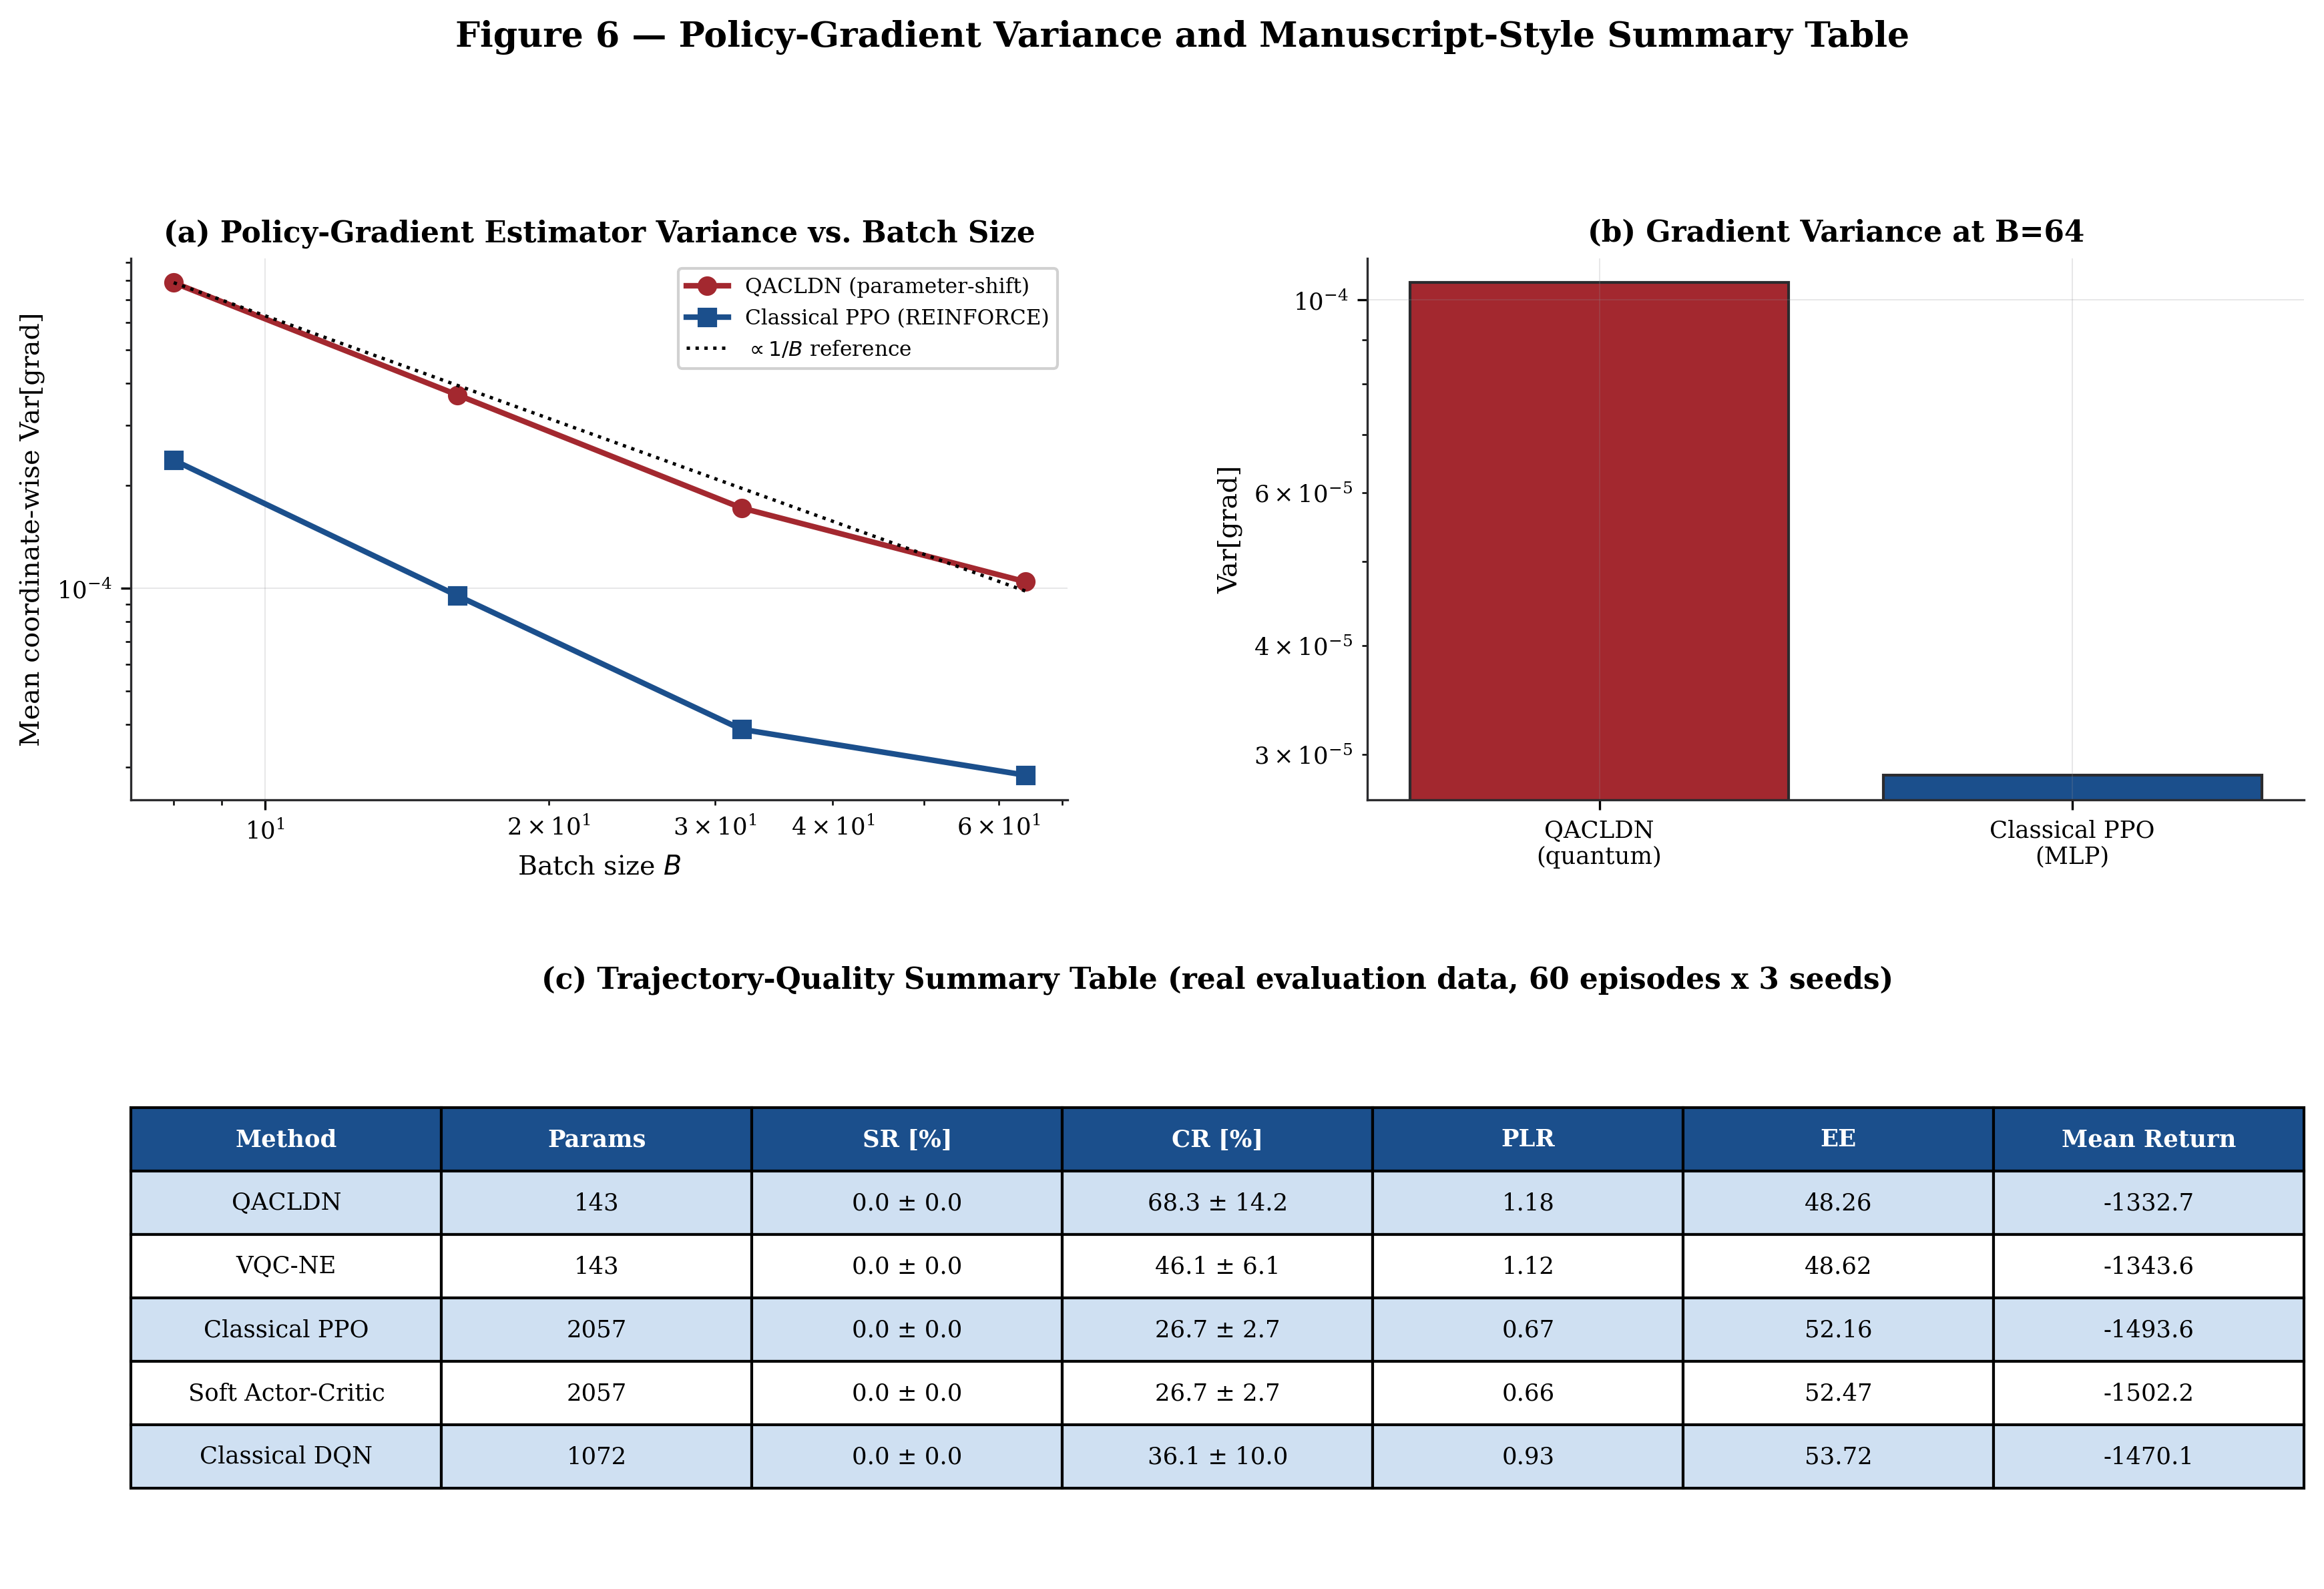

[figures] Figure 6 (gradient variance & summary table) rendered

[figures] all figures written to multi-page PDF: /home/claude/work/outputs/QACLDN_experimental_results.pdf
[figures] individual PNGs written to: /home/claude/work/outputs/figures


In [24]:
fig = plt.figure(figsize=(14, 8.5))
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.42, wspace=0.32)
fig.suptitle("Figure 6 — Policy-Gradient Variance and Manuscript-Style Summary Table",
             fontsize=12.5, fontweight="bold", y=1.02)

ax = fig.add_subplot(gs[0, 0])
ax.loglog(_bs_sweep, grad_var_quantum, "o-", color=PALETTE["dred"], lw=2, label="QACLDN (parameter-shift)")
ax.loglog(_bs_sweep, grad_var_classical, "s-", color=PALETTE["dblue"], lw=2, label="Classical PPO (REINFORCE)")
ref = grad_var_quantum[0] * _bs_sweep[0] / np.array(_bs_sweep)
ax.loglog(_bs_sweep, ref, "k:", lw=1.2, label="$\\propto 1/B$ reference")
style_ax(ax, "(a) Policy-Gradient Estimator Variance vs. Batch Size", "Batch size $B$", "Mean coordinate-wise Var[grad]")
ax.legend(fontsize=7.5, framealpha=0.9)

ax = fig.add_subplot(gs[0, 1])
ax.bar(["QACLDN\n(quantum)", "Classical PPO\n(MLP)"],
       [grad_var_quantum[-1], grad_var_classical[-1]],
       color=[PALETTE["dred"], PALETTE["dblue"]], edgecolor=PALETTE["charcoal"])
style_ax(ax, f"(b) Gradient Variance at B={_bs_sweep[-1]}", "", "Var[grad]")
ax.set_yscale("log")

# (c)+(d): manuscript-style summary table rendered as a figure (Table
# trajectory_results analogue), computed entirely from Experiment 7
ax = fig.add_subplot(gs[1, :])
ax.axis("off")
col_labels = ["Method", "Params", "SR [%]", "CR [%]", "PLR", "EE", "Mean Return"]
rows = []
for m in METHOD_NAMES:
    n_params = (main_agents[m][0].n_total_params if hasattr(main_agents[m][0], "n_total_params") else "-")
    tq = trajectory_quality[m]
    rows.append([m, str(n_params), f"{tq['SR']:.1f} ± {tq['SR_std']:.1f}",
                 f"{tq['CR']:.1f} ± {tq['CR_std']:.1f}", f"{tq['PLR']:.2f}",
                 f"{tq['EE']:.2f}", f"{tq['mean_return']:.1f}"])
table = ax.table(cellText=rows, colLabels=col_labels, loc="center", cellLoc="center")
table.auto_set_font_size(False)
table.set_fontsize(8.5)
table.scale(1.0, 1.9)
for j in range(len(col_labels)):
    table[0, j].set_facecolor(PALETTE["dblue"])
    table[0, j].set_text_props(color="white", fontweight="bold")
for i, m in enumerate(METHOD_NAMES):
    for j in range(len(col_labels)):
        table[i+1, j].set_facecolor(PALETTE["lblue"] if i % 2 == 0 else "white")
ax.set_title("(c) Trajectory-Quality Summary Table (real evaluation data, "
             f"{CFG.n_test_episodes} episodes x {CFG.n_seeds_main} seeds)", fontweight="bold", pad=14)

pdf.savefig(fig, bbox_inches="tight")
fig.savefig(os.path.join(FIG_DIR, "fig6_gradient_variance_summary.png"), bbox_inches="tight")
plt.close(fig)
if Image is not None:
    display(Image(filename=os.path.join(FIG_DIR, "fig6_gradient_variance_summary.png")))
print("[figures] Figure 6 (gradient variance & summary table) rendered")

pdf.close()
print(f"\n[figures] all figures written to multi-page PDF: {PDF_PATH}")
print(f"[figures] individual PNGs written to: {FIG_DIR}")